In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Pregunta 1
Un estudio está interesado en desarrollar un tratamiento efectivo contra los herpes labiales. Recientemente se desarrollaron 4 potenciales tratamientos (t1, t2, t3 y t4). Para evaluar la efectividad de cada tratamiento, se asignaron de forma aleatoria 30 pacientes con brotes labiales, agrupados en 6 muestras (m1, m2, m3, m4, m5 y m6) de 5 pacientes, a los 4 tratamientos más un grupo placebo (control). En cada caso se registró el número de días desde el brote del herpe hasta su completa recuperación. Los resultados del estudio están disponibles en el archivo herpes.xls. A partir de esta información.


## a)	
Realice un análisis preliminar de los datos, incluyendo discusión, y descripción de las variables. ¿Existe algún tratamiento que destaque por sobre otro? ¿Por qué? 

In [3]:
herpes_df = pd.read_excel('herpes.xls')

In [4]:
# description of the treatemnts
muestras = ['m1', 'm2', 'm3', 'm4', 'm5', 'm6']
respuesta_placebo = herpes_df[herpes_df['tratamiento'] == 'placebo'][muestras].values.flatten()
respuesta_t1 = herpes_df[herpes_df['tratamiento'] == 't1'][muestras].values.flatten()
respuesta_t2 = herpes_df[herpes_df['tratamiento'] == 't2'][muestras].values.flatten()
respuesta_t3 = herpes_df[herpes_df['tratamiento'] == 't3'][muestras].values.flatten()
respuesta_t4 = herpes_df[herpes_df['tratamiento'] == 't4'][muestras].values.flatten()

# create a list of the responses

rest_df = pd.DataFrame(0 ,index = ['placebo', 't1', 't2', 't3', 't4'], columns = ['mean', 'std', 'n', 'median', 'min', 'max'],
                       dtype = float)
for tratamiento, respuesta in zip(['placebo', 't1', 't2', 't3', 't4'],
                                  [respuesta_placebo, respuesta_t1, respuesta_t2, respuesta_t3, respuesta_t4]):
    rest_df.loc[tratamiento, 'mean'] = np.mean(respuesta)
    rest_df.loc[tratamiento, 'std'] = np.std(respuesta, ddof=1)
    rest_df.loc[tratamiento, 'n'] = len(respuesta)
    rest_df.loc[tratamiento, 'median'] = np.median(respuesta)
    rest_df.loc[tratamiento, 'min'] = np.min(respuesta)
    rest_df.loc[tratamiento, 'max'] = np.max(respuesta)
rest_df.to_csv('resumen_tratamientos.csv')


Text(0, 0.5, 'Días a Completa Recuperación')

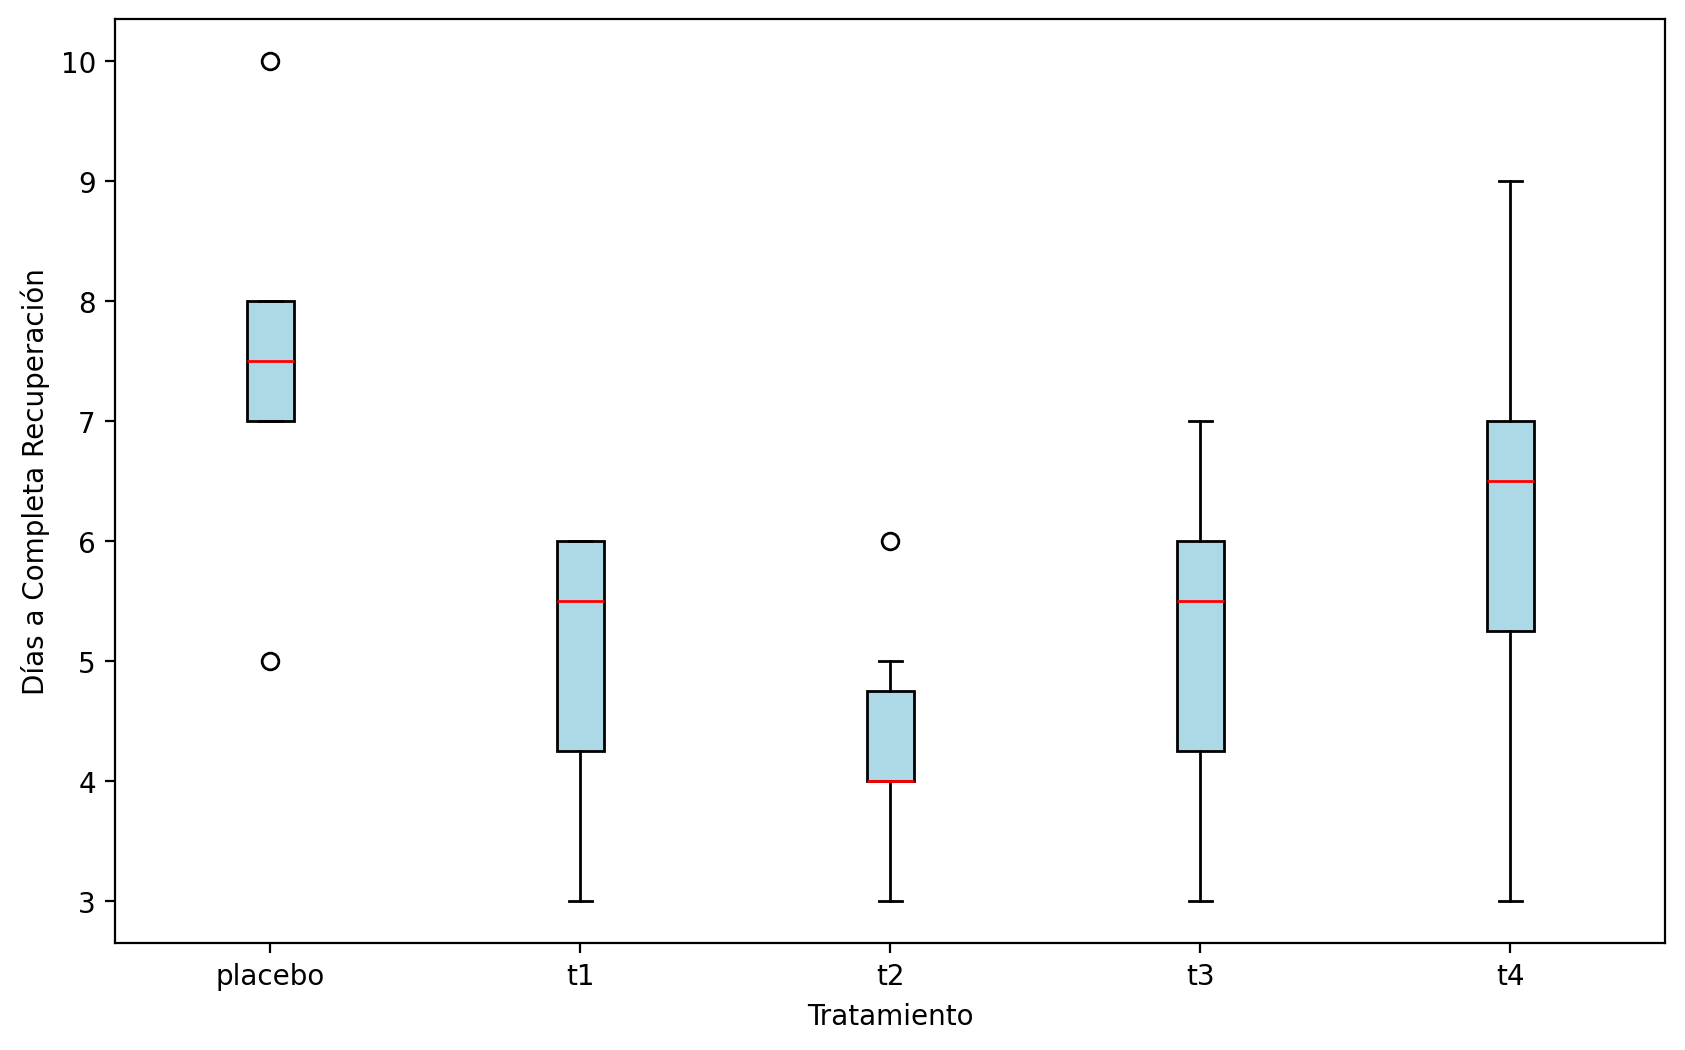

In [5]:
fig, ax = plt.subplots(figsize=(10, 6), dpi = 200)
muestras = ['m1', 'm2', 'm3', 'm4', 'm5', 'm6']
for i, t in enumerate(herpes_df['tratamiento'].unique()):
    subset = herpes_df[herpes_df['tratamiento'] == t]   
    ax.boxplot(subset[muestras].values.flatten(), positions = [i] , widths=0.15, patch_artist=True, 
               boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red'))
ax.set_xticks(range(len(herpes_df['tratamiento'].unique())))
ax.set_xticklabels(herpes_df['tratamiento'].unique())
ax.set_xlabel('Tratamiento')
ax.set_ylabel('Días a Completa Recuperación')

## b)
Reporte la estadística descriptiva (promedio y desviación estándar) y construya un intervalo de confianza al 95% para cada tratamiento. Complemente lo concluido en 1a) a la luz de sus resultados. 

In [6]:
# description of the treatemnts
muestras = ['m1', 'm2', 'm3', 'm4', 'm5', 'm6']
respuesta_placebo = herpes_df[herpes_df['tratamiento'] == 'placebo'][muestras].values.flatten()
respuesta_t1 = herpes_df[herpes_df['tratamiento'] == 't1'][muestras].values.flatten()
respuesta_t2 = herpes_df[herpes_df['tratamiento'] == 't2'][muestras].values.flatten()
respuesta_t3 = herpes_df[herpes_df['tratamiento'] == 't3'][muestras].values.flatten()
respuesta_t4 = herpes_df[herpes_df['tratamiento'] == 't4'][muestras].values.flatten()

# create a list of the responses

rest_df = pd.DataFrame(0 ,index = ['placebo', 't1', 't2', 't3', 't4'], columns = ['mean', 'std', 'n', 'median', 'min', 'max'],
                       dtype = float)
for tratamiento, respuesta in zip(['placebo', 't1', 't2', 't3', 't4'],
                                  [respuesta_placebo, respuesta_t1, respuesta_t2, respuesta_t3, respuesta_t4]):
    rest_df.loc[tratamiento, 'mean'] = np.mean(respuesta)
    rest_df.loc[tratamiento, 'std'] = np.std(respuesta, ddof=1)
    rest_df.loc[tratamiento, 'n'] = len(respuesta)
    rest_df.loc[tratamiento, 'median'] = np.median(respuesta)
    rest_df.loc[tratamiento, 'min'] = np.min(respuesta)
    rest_df.loc[tratamiento, 'max'] = np.max(respuesta)
print(rest_df)

             mean       std    n  median  min   max
placebo  7.500000  1.643168  6.0     7.5  5.0  10.0
t1       5.000000  1.264911  6.0     5.5  3.0   6.0
t2       4.333333  1.032796  6.0     4.0  3.0   6.0
t3       5.166667  1.471960  6.0     5.5  3.0   7.0
t4       6.166667  2.041241  6.0     6.5  3.0   9.0


In [7]:
def intervalos_confianza(data, alpha=0.05):
    n = data['n']
    mean = data['mean']
    std = data['std']
    z = stats.t.ppf(1 - alpha / 2, df = n - 1)  # Z-score for the confidence level
    margin_of_error = z * (std / np.sqrt(n))
    lower_bound = mean - margin_of_error
    upper_bound = mean + margin_of_error
    return pd.Series({'lower_bound': lower_bound, 'upper_bound': upper_bound})
# Calculate confidence intervals for each treatment
conf_intervals = rest_df.apply(intervalos_confianza, axis=1)
# Print the confidence intervals
print("\nConfidence Intervals:")
display(conf_intervals)


Confidence Intervals:


,lower_bound,upper_bound
placebo,5.775601,9.224399
t1,3.672557,6.327443
t2,3.249481,5.417186
t3,3.621939,6.711394
t4,4.024515,8.308818


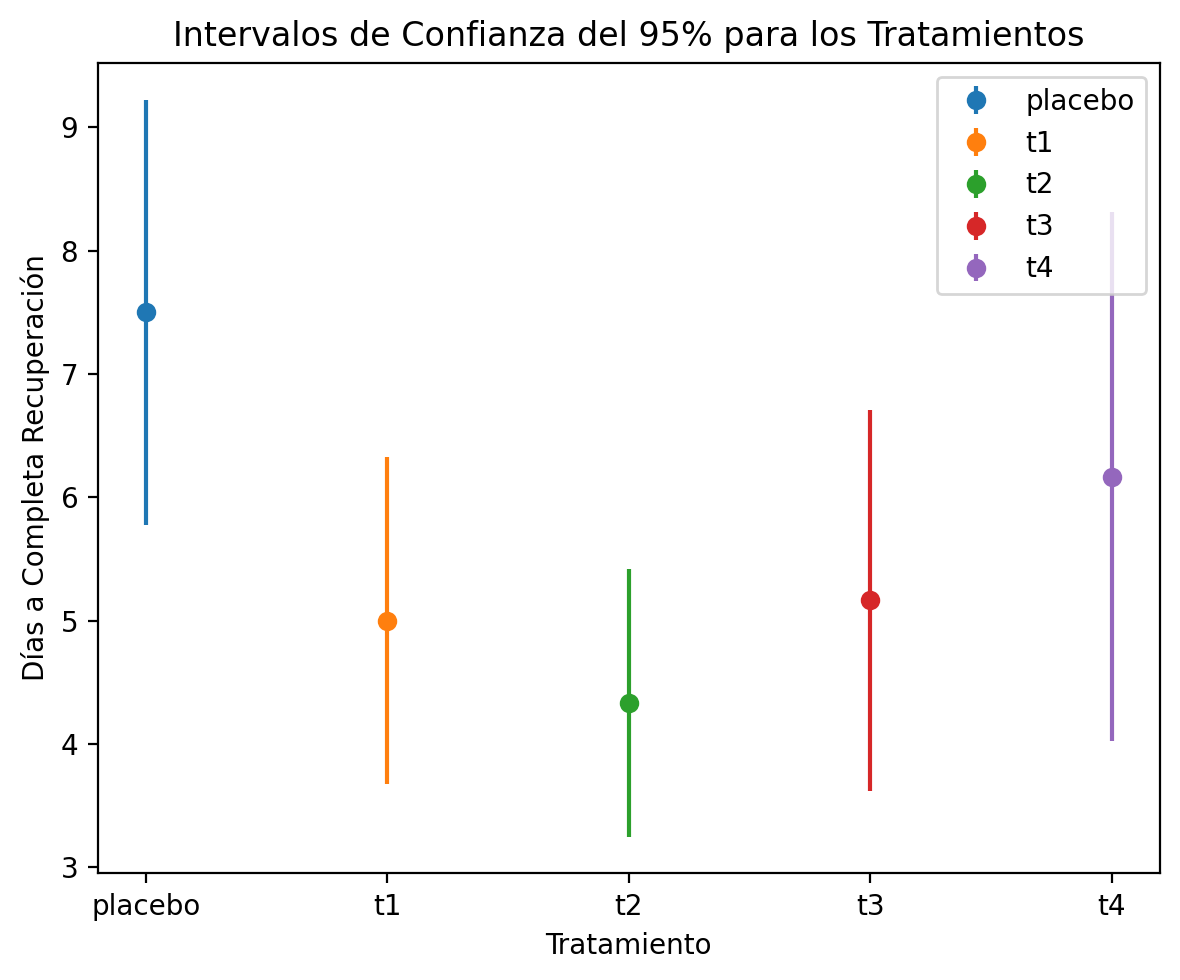

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
# Plotting the confidence intervals
for i, treatment in enumerate(rest_df.index):
    mean = rest_df.loc[treatment, 'mean']
    lower_bound = conf_intervals.loc[treatment, 'lower_bound']
    upper_bound = conf_intervals.loc[treatment, 'upper_bound']
    
    ax.errorbar(i, mean, yerr=[[mean - lower_bound], [upper_bound - mean]], fmt='o', label=treatment)
ax.set_xticks(range(len(rest_df.index)))
ax.set_xticklabels(rest_df.index)
ax.set_xlabel('Tratamiento')
ax.set_ylabel('Días a Completa Recuperación')
ax.set_title('Intervalos de Confianza del 95% para los Tratamientos')
ax.legend()
plt.tight_layout()

## c)	
Compruebe la respuesta anterior mediante una prueba de hipótesis utilizando un nivel de significancia α = 0.05. Siga los lineamientos de prueba de hipótesis mencionada en clases. 

,tratamiento,W,p_value
0,placebo,0.951391,0.751529
1,t1,0.831142,0.109908
2,t2,0.915459,0.473271
3,t3,0.958012,0.804296
4,t4,0.975245,0.925628


Levene's Test: Statistic=0.5851, p-value=0.6763


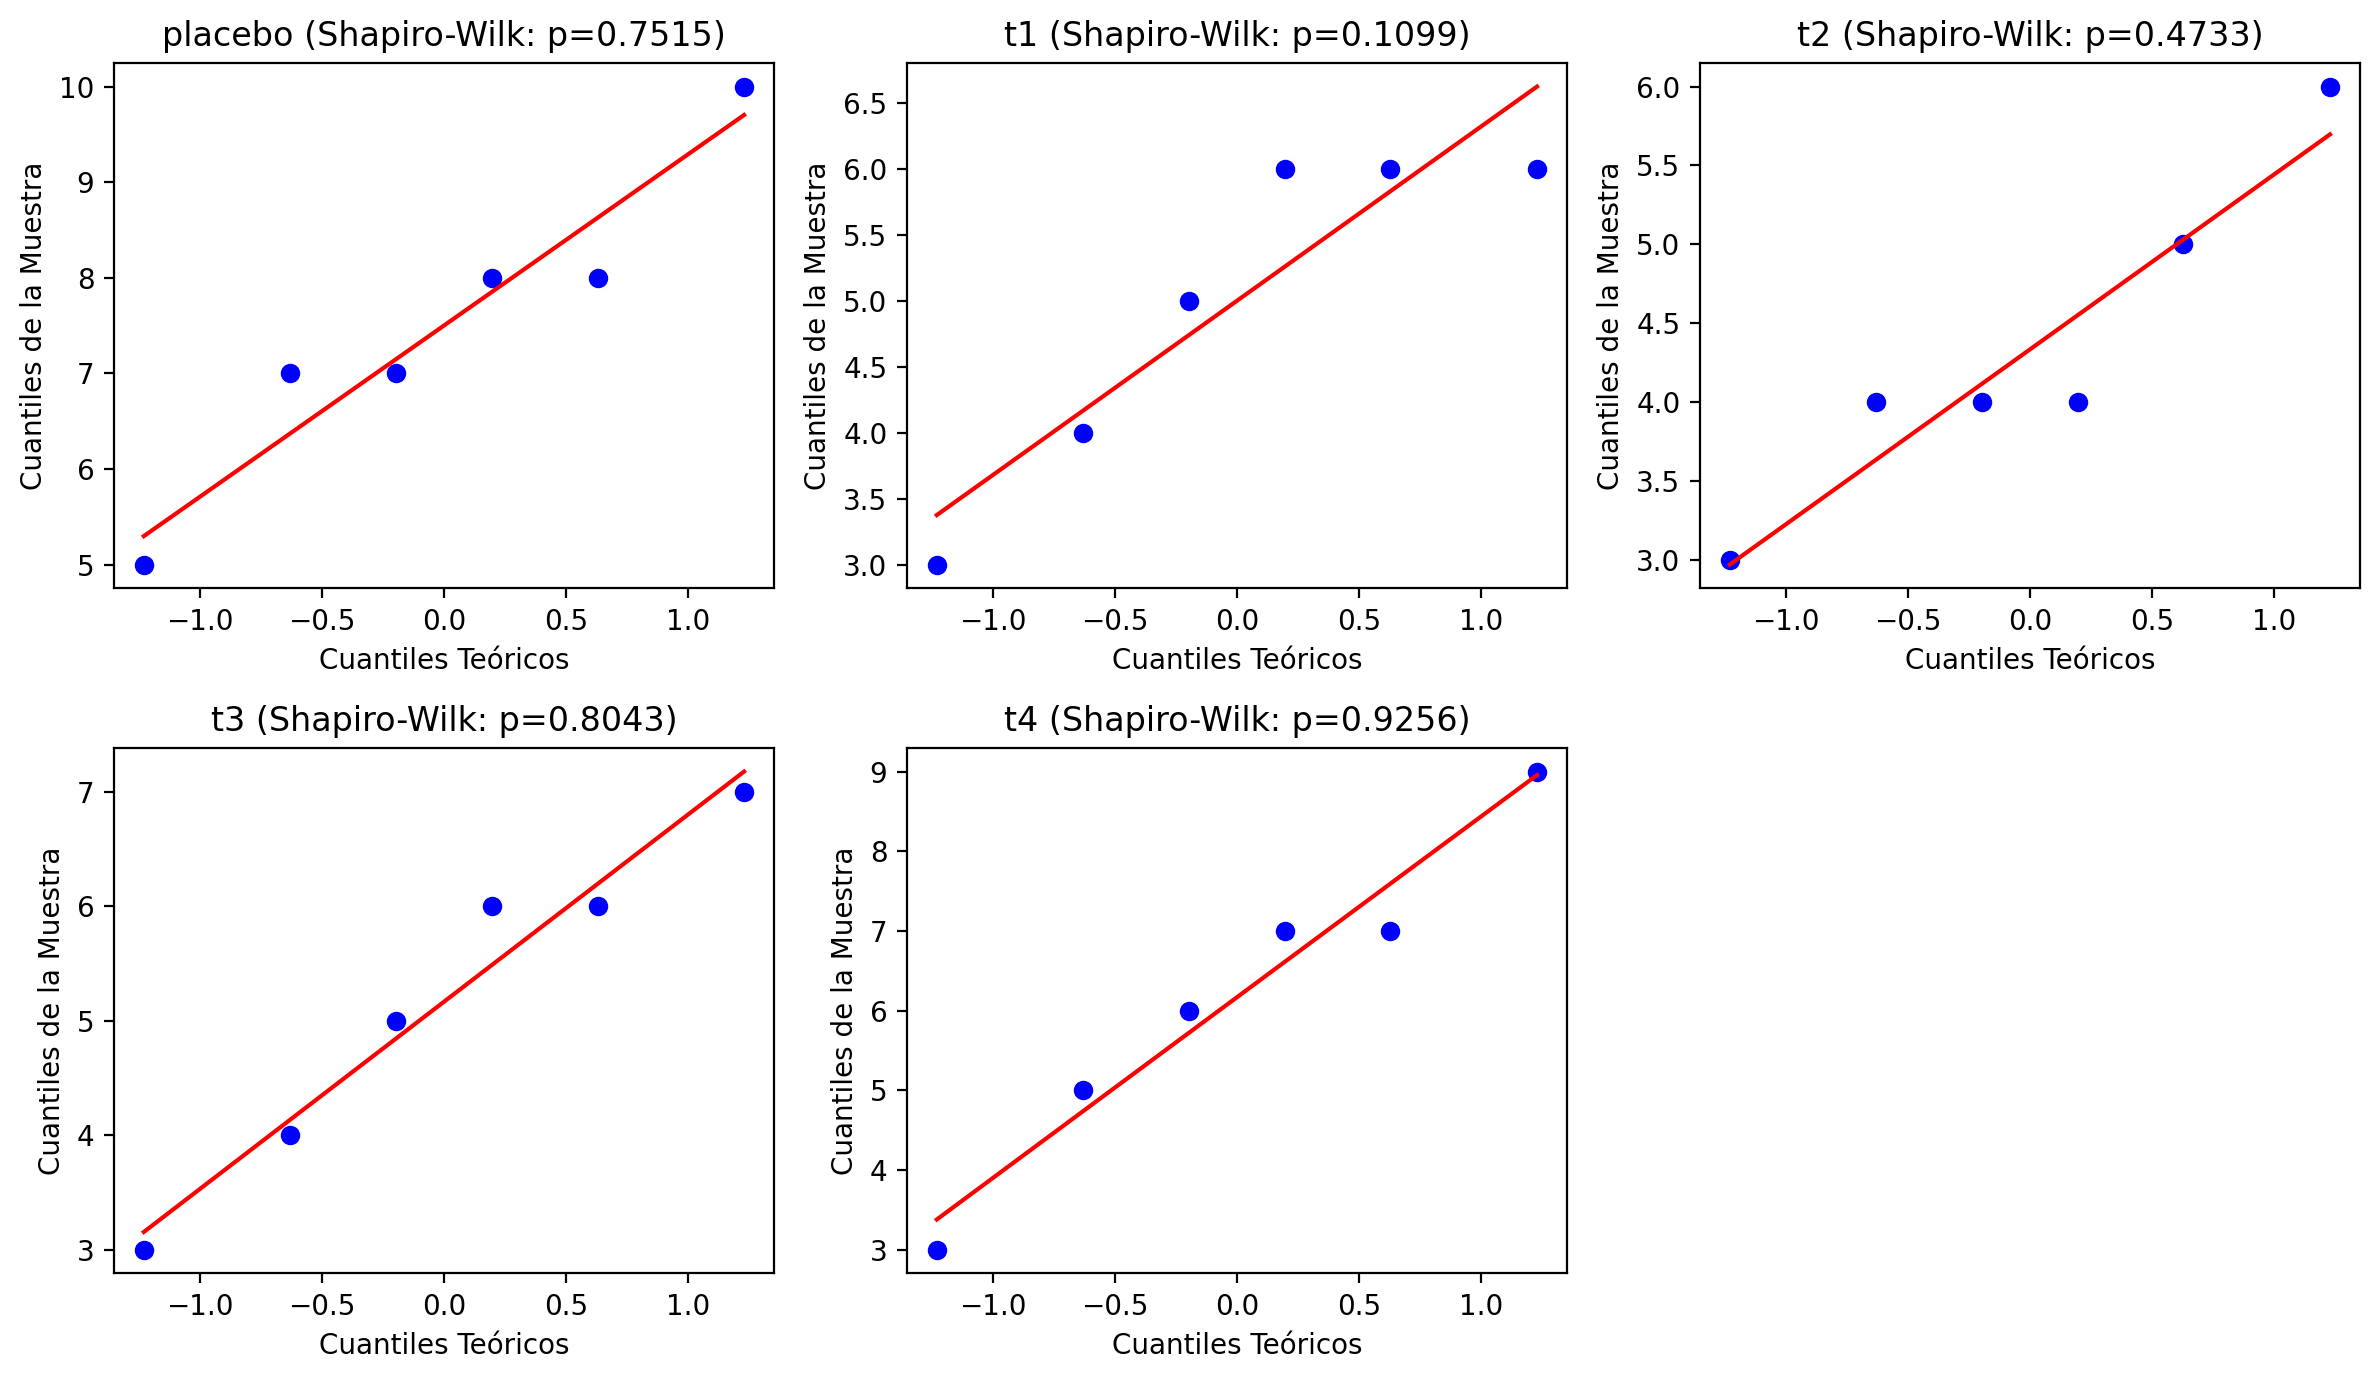

In [9]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pingouin import ptests, pairwise_tests

respuesta_placebo = herpes_df[herpes_df['tratamiento'] == 'placebo'][muestras].values.flatten()
respuesta_t1 = herpes_df[herpes_df['tratamiento'] == 't1'][muestras].values.flatten()
respuesta_t2 = herpes_df[herpes_df['tratamiento'] == 't2'][muestras].values.flatten()
respuesta_t3 = herpes_df[herpes_df['tratamiento'] == 't3'][muestras].values.flatten()
respuesta_t4 = herpes_df[herpes_df['tratamiento'] == 't4'][muestras].values.flatten()
#### shapiro wilk 

tratamientos = {
    'placebo': respuesta_placebo,
    't1': respuesta_t1,
    't2': respuesta_t2,
    't3': respuesta_t3,
    't4': respuesta_t4
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7), dpi=200)
axes = axes.flatten()
shapiro_rows = []

for idx, (nombre, valores) in enumerate(tratamientos.items()):
    stat, p_value = stats.shapiro(valores)
    shapiro_rows.append({'tratamiento': nombre, 'W': stat, 'p_value': p_value})
    stats.probplot(valores, dist='norm', plot=axes[idx])
    axes[idx].set_title(f"{nombre} (Shapiro-Wilk: p={p_value:.4f})")
    axes[idx].set_xlabel('Cuantiles Teóricos')
    axes[idx].set_ylabel('Cuantiles de la Muestra')

axes[-1].axis('off')
plt.tight_layout()
display(pd.DataFrame(shapiro_rows))

#### LEVENE
levene_stat, levene_p = stats.levene(respuesta_placebo, respuesta_t1, respuesta_t2, respuesta_t3, respuesta_t4)
print(f"Levene's Test: Statistic={levene_stat:.4f}, p-value={levene_p:.4f}")

In [10]:


data_anova = pd.DataFrame({
    'respuesta': np.concatenate([respuesta_placebo, respuesta_t1, respuesta_t2, respuesta_t3, respuesta_t4]),
    'tratamiento': np.repeat(herpes_df['tratamiento'].unique(), len(muestras))
})
anova_model = ols('respuesta ~ C(tratamiento)', data=data_anova).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=1)
anova_table.round(4).to_csv('anova_table.csv')
print(anova_table)


                  df     sum_sq   mean_sq         F   PR(>F)
C(tratamiento)   4.0  36.466667  9.116667  3.896011  0.01359
Residual        25.0  58.500000  2.340000       NaN      NaN


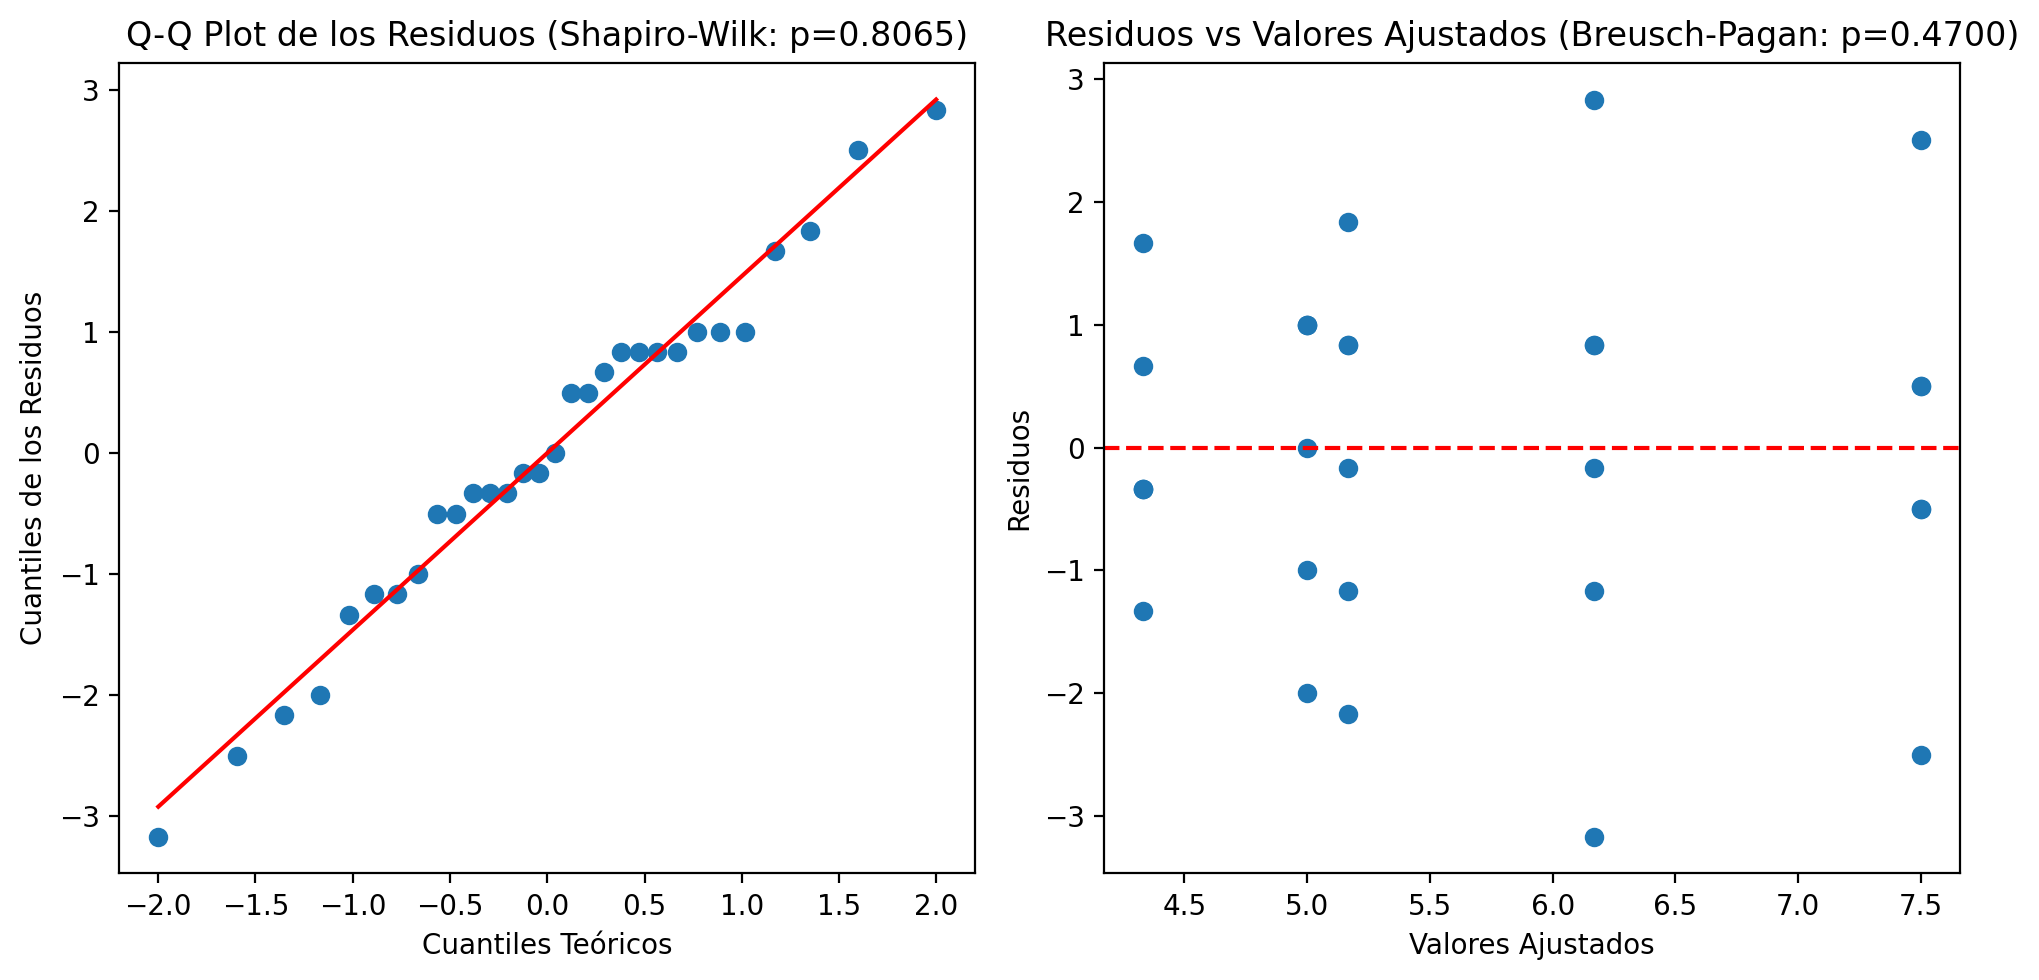

In [11]:
resid = anova_model.resid
fig, ax = plt.subplots(1,2,figsize=(10, 5), dpi=200)
# normalidad
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
ax[0].scatter(osm, osr)
ax[0].plot(osm, slope*osm + intercept, color='red')
ax[0].set_title('Q-Q Plot de los Residuos')
ax[0].set_xlabel('Cuantiles Teóricos')
ax[0].set_ylabel('Cuantiles de los Residuos')
shapiro_stat, shapiro_p = stats.shapiro(resid)
ax[0].set_title(
    f'Q-Q Plot de los Residuos (Shapiro-Wilk: p={shapiro_p:.4f})'
)
# homocedasticidad  
ax[1].scatter(anova_model.fittedvalues, resid)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Residuos vs Valores Ajustados')
ax[1].set_xlabel('Valores Ajustados')
ax[1].set_ylabel('Residuos')
lm, lm_p, fvalue, f_p = sm.stats.diagnostic.het_breuschpagan(resid, anova_model.model.exog)
ax[1].set_title(
    f'Residuos vs Valores Ajustados (Breusch-Pagan: p={lm_p:.4f})'
)
plt.tight_layout()

Se concluye que existen diferencias entre tratamientos

## D)

En el caso que existan diferencias significativas, ¿Cuál(es) de los niveles son estadísticamente diferentes entre sí? En el caso que no haya diferencias, discuta brevemente porqué pudo no haberse observado diferencias. 

In [12]:
pairwise_comp = pairwise_tests(data=data_anova, dv='respuesta', between='tratamiento', padjust='bonf')
print("\nPairwise Comparisons:")
pairwise_comp.round(4).to_csv('pairwise_comparisons.csv')
display(pairwise_comp)
# Show the plots


Pairwise Comparisons:


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,tratamiento,placebo,t1,False,True,2.953122,10.0,two-sided,0.014457,0.144572,bonf,4.058,1.573833
1,tratamiento,placebo,t2,False,True,3.996680,10.0,two-sided,0.002532,0.025319,bonf,13.975,2.129986
2,tratamiento,placebo,t3,False,True,2.590816,10.0,two-sided,0.026912,0.269122,bonf,2.69,1.380746
3,tratamiento,placebo,t4,False,True,1.246354,10.0,two-sided,0.241040,1.000000,bonf,0.752,0.664230
4,tratamiento,t1,t2,False,True,1.000000,10.0,two-sided,0.340893,1.000000,bonf,0.639,0.532939
5,tratamiento,t1,t3,False,True,-0.210352,10.0,two-sided,0.837617,1.000000,bonf,0.474,-0.112105
6,tratamiento,t1,t4,False,True,-1.190036,10.0,two-sided,0.261518,1.000000,bonf,0.722,-0.634216
7,tratamiento,t2,t3,False,True,-1.135192,10.0,two-sided,0.282771,1.000000,bonf,0.696,-0.604988
8,tratamiento,t2,t4,False,True,-1.963034,10.0,two-sided,0.078042,0.780422,bonf,1.391,-1.046177
9,tratamiento,t3,t4,False,True,-0.973329,10.0,two-sided,0.353345,1.000000,bonf,0.629,-0.518724


In [13]:
pairwise_comp = pairwise_tests(data=data_anova, dv='respuesta', between='tratamiento', padjust='bonf',
                               alternative='greater')
print("\nPairwise Comparisons:")
pairwise_comp.round(4).to_csv('pairwise_comparisons_greater.csv')
display(pairwise_comp)


Pairwise Comparisons:


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,hedges
0,tratamiento,placebo,t1,False,True,2.953122,10.0,greater,0.007229,0.072286,bonf,1.573833
1,tratamiento,placebo,t2,False,True,3.996680,10.0,greater,0.001266,0.012659,bonf,2.129986
2,tratamiento,placebo,t3,False,True,2.590816,10.0,greater,0.013456,0.134561,bonf,1.380746
3,tratamiento,placebo,t4,False,True,1.246354,10.0,greater,0.120520,1.000000,bonf,0.664230
4,tratamiento,t1,t2,False,True,1.000000,10.0,greater,0.170447,1.000000,bonf,0.532939
5,tratamiento,t1,t3,False,True,-0.210352,10.0,greater,0.581191,1.000000,bonf,-0.112105
6,tratamiento,t1,t4,False,True,-1.190036,10.0,greater,0.869241,1.000000,bonf,-0.634216
7,tratamiento,t2,t3,False,True,-1.135192,10.0,greater,0.858614,1.000000,bonf,-0.604988
8,tratamiento,t2,t4,False,True,-1.963034,10.0,greater,0.960979,1.000000,bonf,-1.046177
9,tratamiento,t3,t4,False,True,-0.973329,10.0,greater,0.823327,1.000000,bonf,-0.518724


## e)
¿Cuál recomendación daría Ud. como asesor experto para continuar este estudio? Comente a partir de los resultados obtenidos.

Recomendación: t2

# 2.

Se analizó el efecto del ácido linoleico en la dieta de 17 individuos por 4 semanas como parte de un estudio de enfermedades cardiovasculares. Se midió la presión sanguínea (sistólica) antes de las 4 semanas (línea base), y luego transcurridas 4 semanas. Los resultados del estudio se reportan en el archivo presion.xls. A partir de esta información, responda:

In [14]:
# carga de datos
import pandas as pd

data = {
    "Experimento": list(range(1, 18)),
    "vert_tenue":  [300, 240, 250, 220, 160, 170, 300, 180, 200,  80, 190, 270, 130, 190, 190, 120, 180],
    "horiz_tenue": [295, 260, 280, 250, 160, 150, 290, 120, 210, 120, 240, 270, 150, 210, 200, 160, 160],
    "vert_claro":  [ 80, 120, 170,  90, 150, 110, 260, 240, 190, 120, 160, 300, 160, 300, 280, 190, 100],
    "horiz_claro": [ 60, 140, 160, 120, 180,  90, 120, 220, 210, 150, 160, 330, 100, 240, 190, 170, 100],
}

df = pd.DataFrame(data).set_index("Experimento")
print(df)
df.describe().to_csv('resumen_experimentos.csv')

             vert_tenue  horiz_tenue  vert_claro  horiz_claro
Experimento                                                  
1                   300          295          80           60
2                   240          260         120          140
3                   250          280         170          160
4                   220          250          90          120
5                   160          160         150          180
6                   170          150         110           90
7                   300          290         260          120
8                   180          120         240          220
9                   200          210         190          210
10                   80          120         120          150
11                  190          240         160          160
12                  270          270         300          330
13                  130          150         160          100
14                  190          210         300          240
15      

## a)

¿Existe alguna relación entre el tamaño de la tela de araña (vertical o horizontal) frente a un régimen de luz (claro o tenue)? Justifique su respuesta usando estadísticos y/o gráficos relevantes 

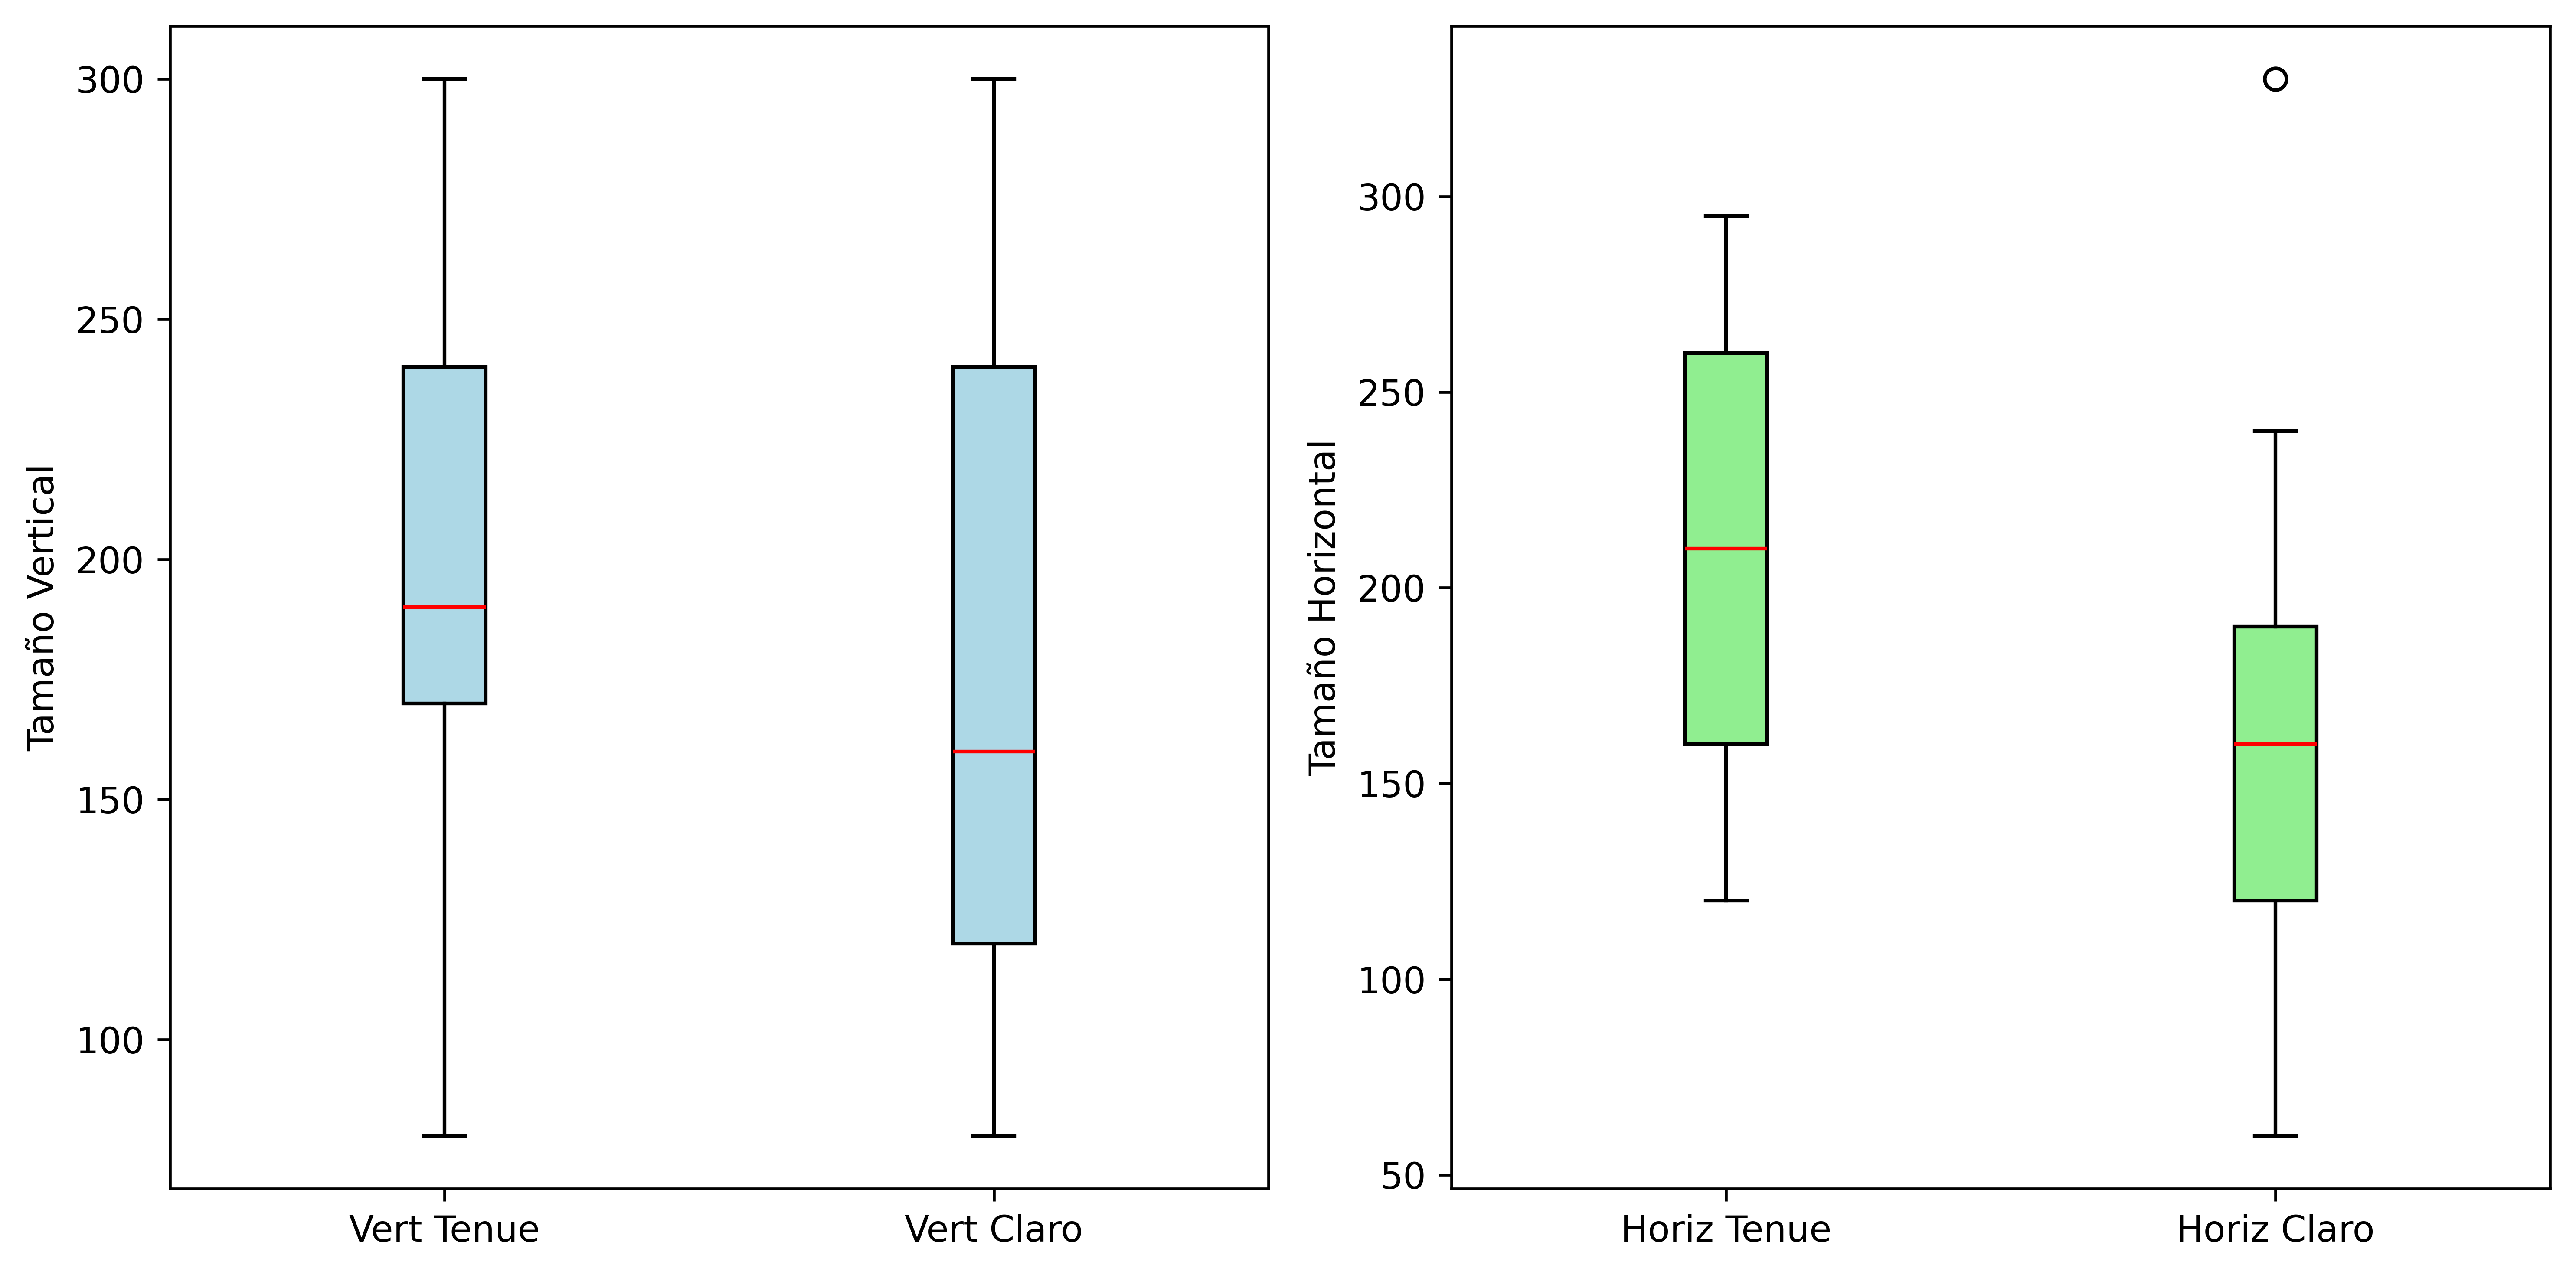

In [15]:
# 
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=600)
ax[0].boxplot([df['vert_tenue'], df['vert_claro']], tick_labels=['Vert Tenue', 'Vert Claro'], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red'))
ax[0].set_ylabel('Tamaño Vertical')
# horizontal
ax[1].boxplot([df['horiz_tenue'], df['horiz_claro']], tick_labels=['Horiz Tenue', 'Horiz Claro'], patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='black'), medianprops=dict(color='red'))
ax[1].set_ylabel('Tamaño Horizontal')
plt.tight_layout()


## b) 
Evalúe la respuesta anterior tanto para el tamaño vertical como horizontal, aplicando una prueba de hipótesis paramétrica utilizando un nivel de significancia α = 0.05. Siga los lineamientos de prueba de hipótesis (1.5 puntos). Justifique la prueba de hipótesis utilizada (1 puntos)


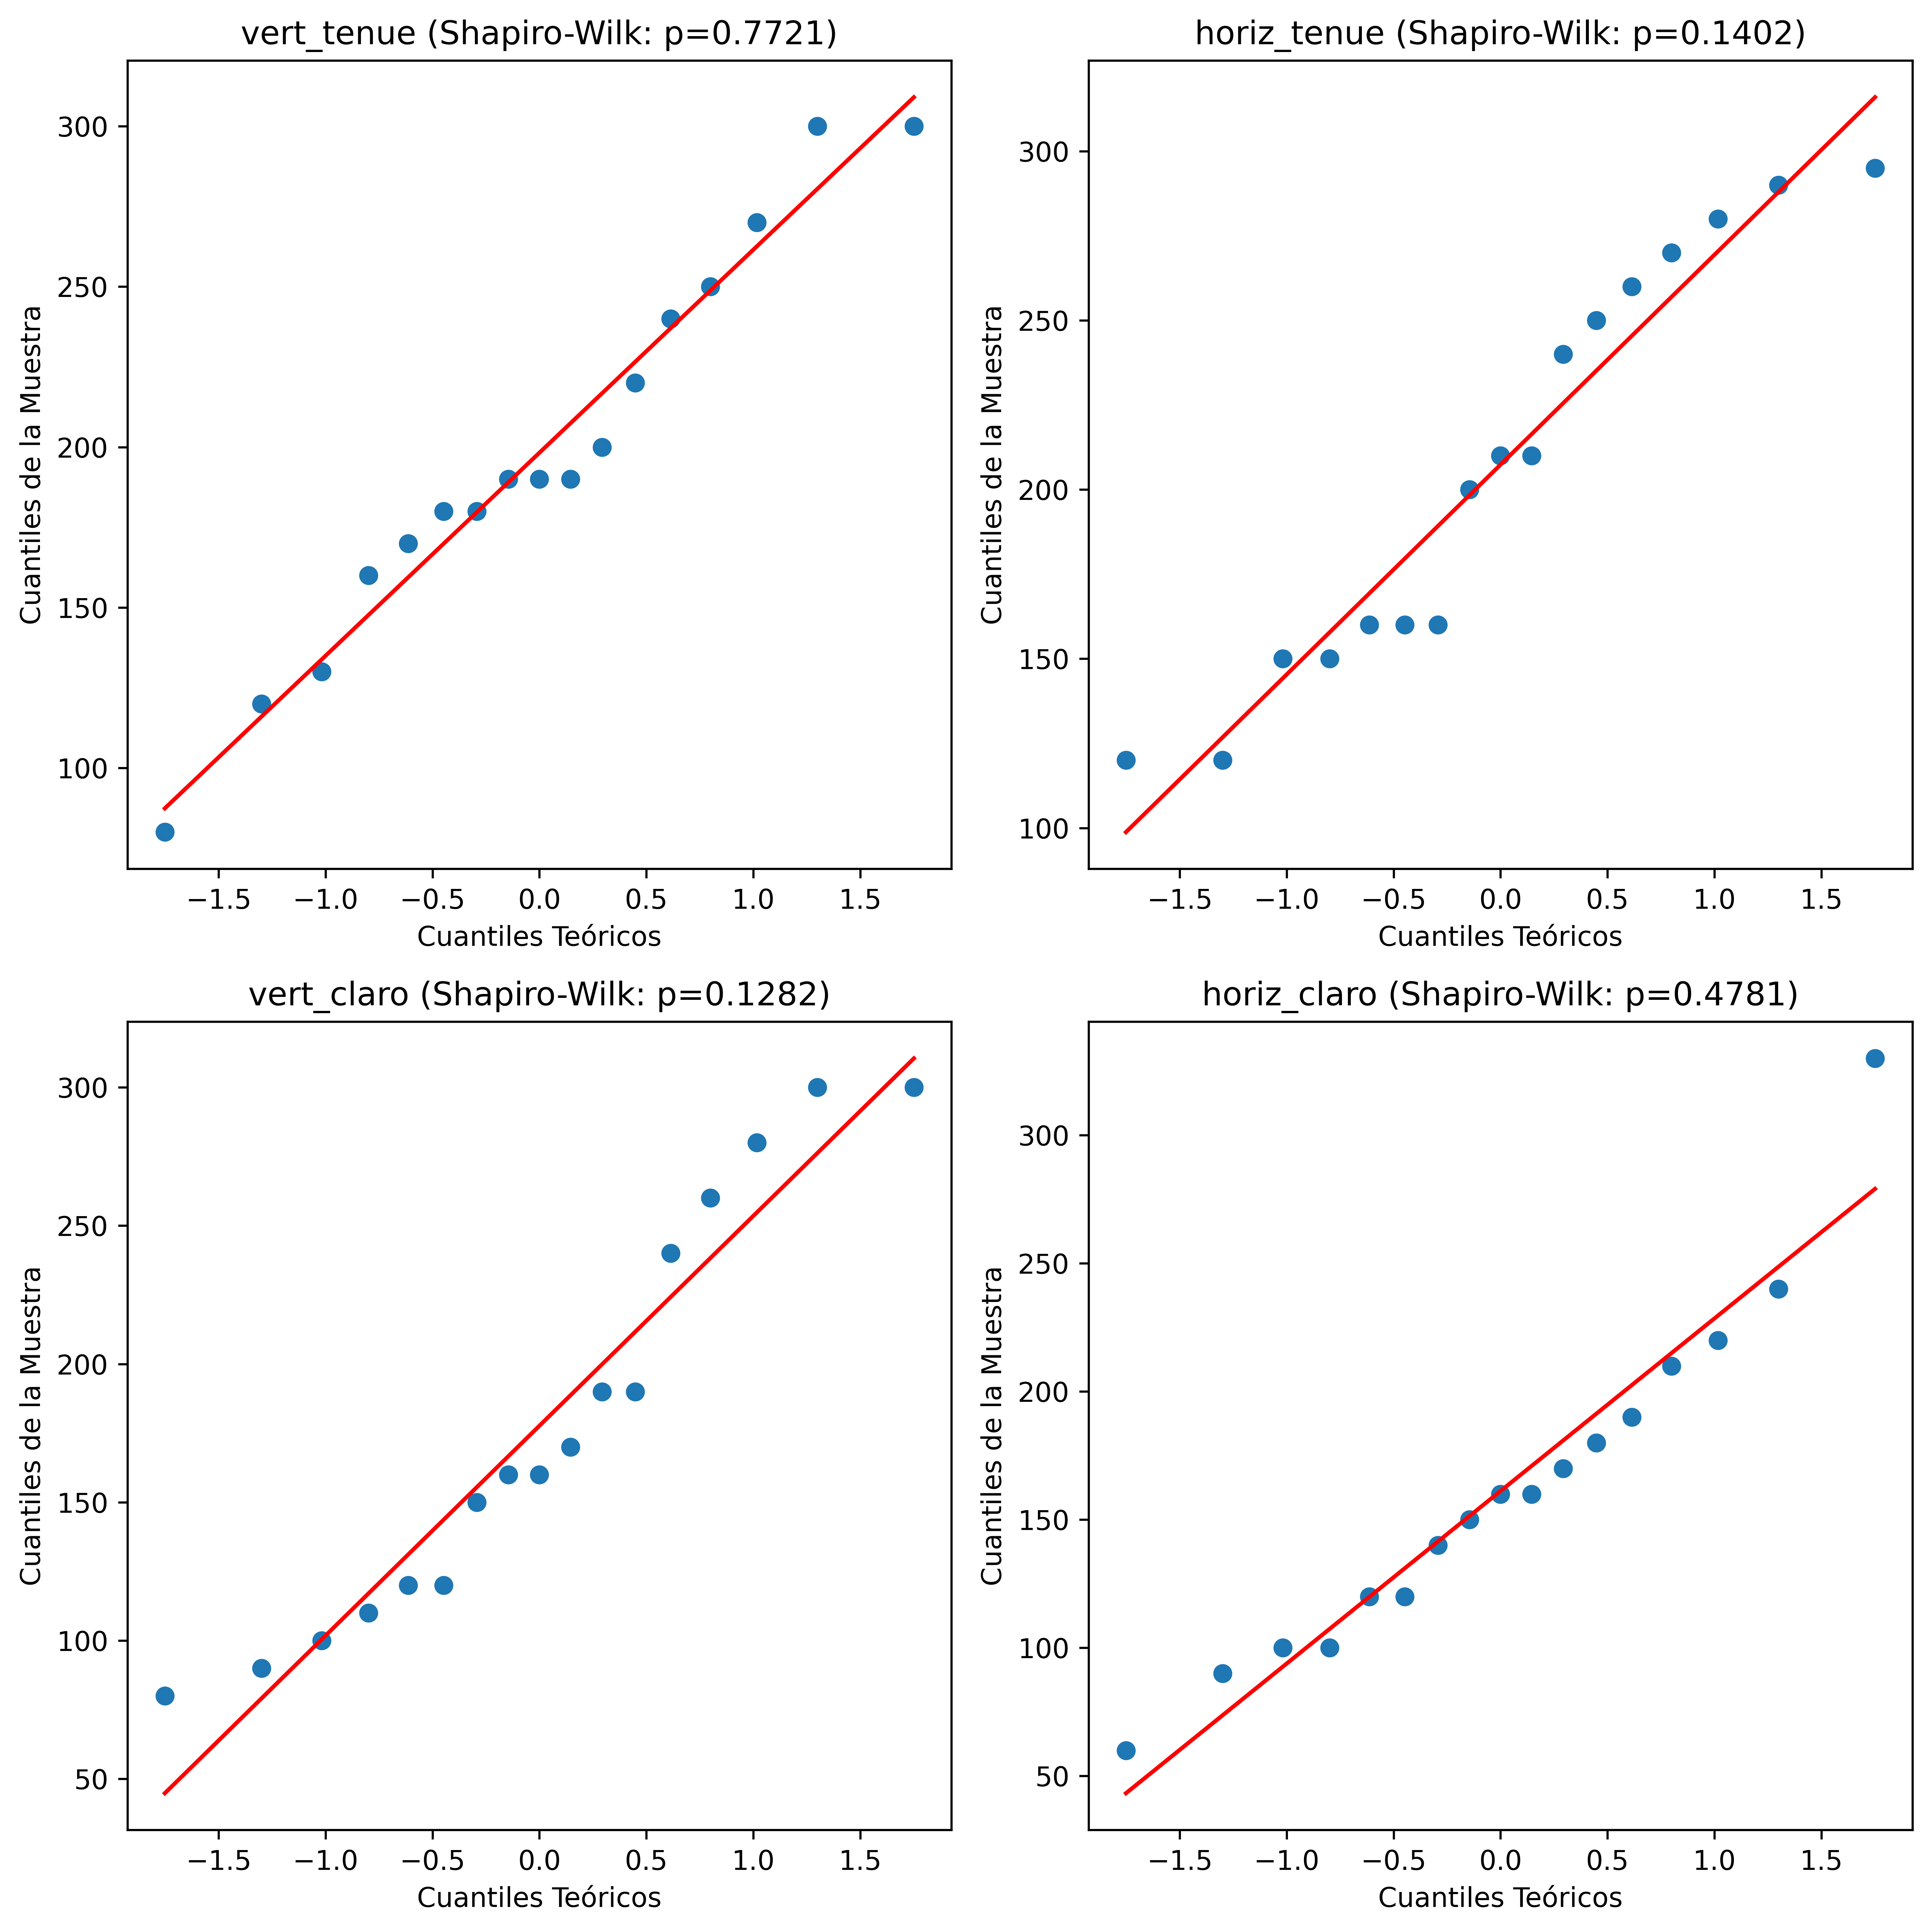

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), dpi=600)
# shapirossss
for i, col in enumerate(df.columns):
    (osm, osr), (slope, intercept, r) = stats.probplot(df[col], dist='norm')
    ax[i//2, i%2].scatter(osm, osr)
    ax[i//2, i%2].plot(osm, slope*osm + intercept, color='red')
    ax[i//2, i%2].set_title(f"{col} (Shapiro-Wilk: p={stats.shapiro(df[col])[1]:.4f})")
    ax[i//2, i%2].set_xlabel('Cuantiles Teóricos')
    ax[i//2, i%2].set_ylabel('Cuantiles de la Muestra')
plt.tight_layout()

In [17]:
from scipy.stats import ttest_rel 
# diferencias vertical
t_stat_vert, p_value_vert = ttest_rel(df['vert_tenue'], df['vert_claro'], alternative='two-sided')
print("\nT-test Result for Vertical:")
print(f"t-statistic: {t_stat_vert:.4f}, p-value: {p_value_vert:.4f}")

# diferencias horizontal
t_stat_horiz, p_value_horiz = ttest_rel(df['horiz_tenue'], df['horiz_claro'], alternative='two-sided')
print("\nT-test Result for Horizontal:")
print(f"t-statistic: {t_stat_horiz:.4f}, p-value: {p_value_horiz:.4f}")

# tenue > claro
t_stat_horiz_greater, p_value_horiz_greater = ttest_rel(df['horiz_tenue'], df['horiz_claro'], alternative='greater')
print("\nT-test Result for Horizontal (Tenue > Claro):")
print(f"t-statistic: {t_stat_horiz_greater:.4f}, p-value: {p_value_horiz_greater:.4f}")
# tenue < claro
t_stat_horiz_less, p_value_horiz_less = ttest_rel(df['horiz_tenue'], df['horiz_claro'], alternative='less')
print("\nT-test Result for Horizontal (Tenue < Claro):")
print(f"t-statistic: {t_stat_horiz_less:.4f}, p-value: {p_value_horiz_less:.4f}")






T-test Result for Vertical:
t-statistic: 0.9654, p-value: 0.3487

T-test Result for Horizontal:
t-statistic: 2.1482, p-value: 0.0474

T-test Result for Horizontal (Tenue > Claro):
t-statistic: 2.1482, p-value: 0.0237

T-test Result for Horizontal (Tenue < Claro):
t-statistic: 2.1482, p-value: 0.9763


## c)

¿Qué test no paramétrico se podría usar en este caso? Explique. Además, realice este test y determine el valor-p crítico y el intervalo de confianza del 95%. ¿Qué se puede concluir?

test de Wilcoxon

In [18]:
from scipy.stats import wilcoxon
# diferencias vertical
t_stat_vert, p_value_vert = wilcoxon(df['vert_tenue'], df['vert_claro'], alternative='two-sided')
print("\nWilcoxon Test Result for Vertical:")
print(f"statistic: {t_stat_vert}, p-value: {p_value_vert:.4f}")

# diferencias horizontal
t_stat_horiz, p_value_horiz = wilcoxon(df['horiz_tenue'], df['horiz_claro'], alternative='two-sided')
print("\nWilcoxon Test Result for Horizontal:")
print(f"statistic: {t_stat_horiz}, p-value: {p_value_horiz:.4f}")

# tenue > claro
t_stat_horiz_greater, p_value_horiz_greater = wilcoxon(df['horiz_tenue'], df['horiz_claro'], alternative='greater')
print("\nWilcoxon Test Result for Horizontal (Tenue > Claro):")
print(f"statistic: {t_stat_horiz_greater}, p-value: {p_value_horiz_greater:.4f}")
# tenue < claro
t_stat_horiz_less, p_value_horiz_less = wilcoxon(df['horiz_tenue'], df['horiz_claro'], alternative='less')
print("\nWilcoxon Test Result for Horizontal (Tenue < Claro):")
print(f"statistic: {t_stat_horiz_less}, p-value: {p_value_horiz_less:.4f}")





Wilcoxon Test Result for Vertical:
statistic: 60.0, p-value: 0.4342

Wilcoxon Test Result for Horizontal:
statistic: 32.5, p-value: 0.0661

Wilcoxon Test Result for Horizontal (Tenue > Claro):
statistic: 103.5, p-value: 0.0330

Wilcoxon Test Result for Horizontal (Tenue < Claro):
statistic: 103.5, p-value: 0.9670


## d)
Discuta los resultados obtenidos con ambos tests. ¿Qué test es más apropiado? Explique.

Respuesta: t-test

# 3

Los datos presentados en el archivo jet.xls presentan el impulso de un motor de turbina de jet (y) y cinco variables explicativas potenciales: la rotación primaria de velocidad (x1), la velocidad secundaria de rotación (x2), la tasa de flujo de combustible (x3), la presión del sistema (x4), y la temperatura de escape (x5). A partir de esta información:

## a)
Realice un análisis exploratorio de los datos. Evalúe la asociación de cada variable explicativa con la variable respuesta (y). ¿Qué variables podrían presentar una asociación con el impulso del motor de turbina de jet (y)? ¿Cuáles no? Reporte resúmenes estadísticos que permitan determinar asociación entre variables (2.5 puntos)

In [19]:
jet_df = pd.read_excel('jet.xls', index_col=0)
display(jet_df)

,x1,x2,x3,x4,x5,y
obs,,,,,,
1,3,3,3,3,0,0.787
2,8,20,8,8,0,0.293
3,3,6,6,6,0,1.710
4,4,4,4,12,0,0.203
5,8,7,6,5,0,0.806
6,10,20,5,5,0,4.713
7,8,6,3,3,25,0.607
8,6,24,4,4,25,9.107
9,4,10,12,4,25,9.210


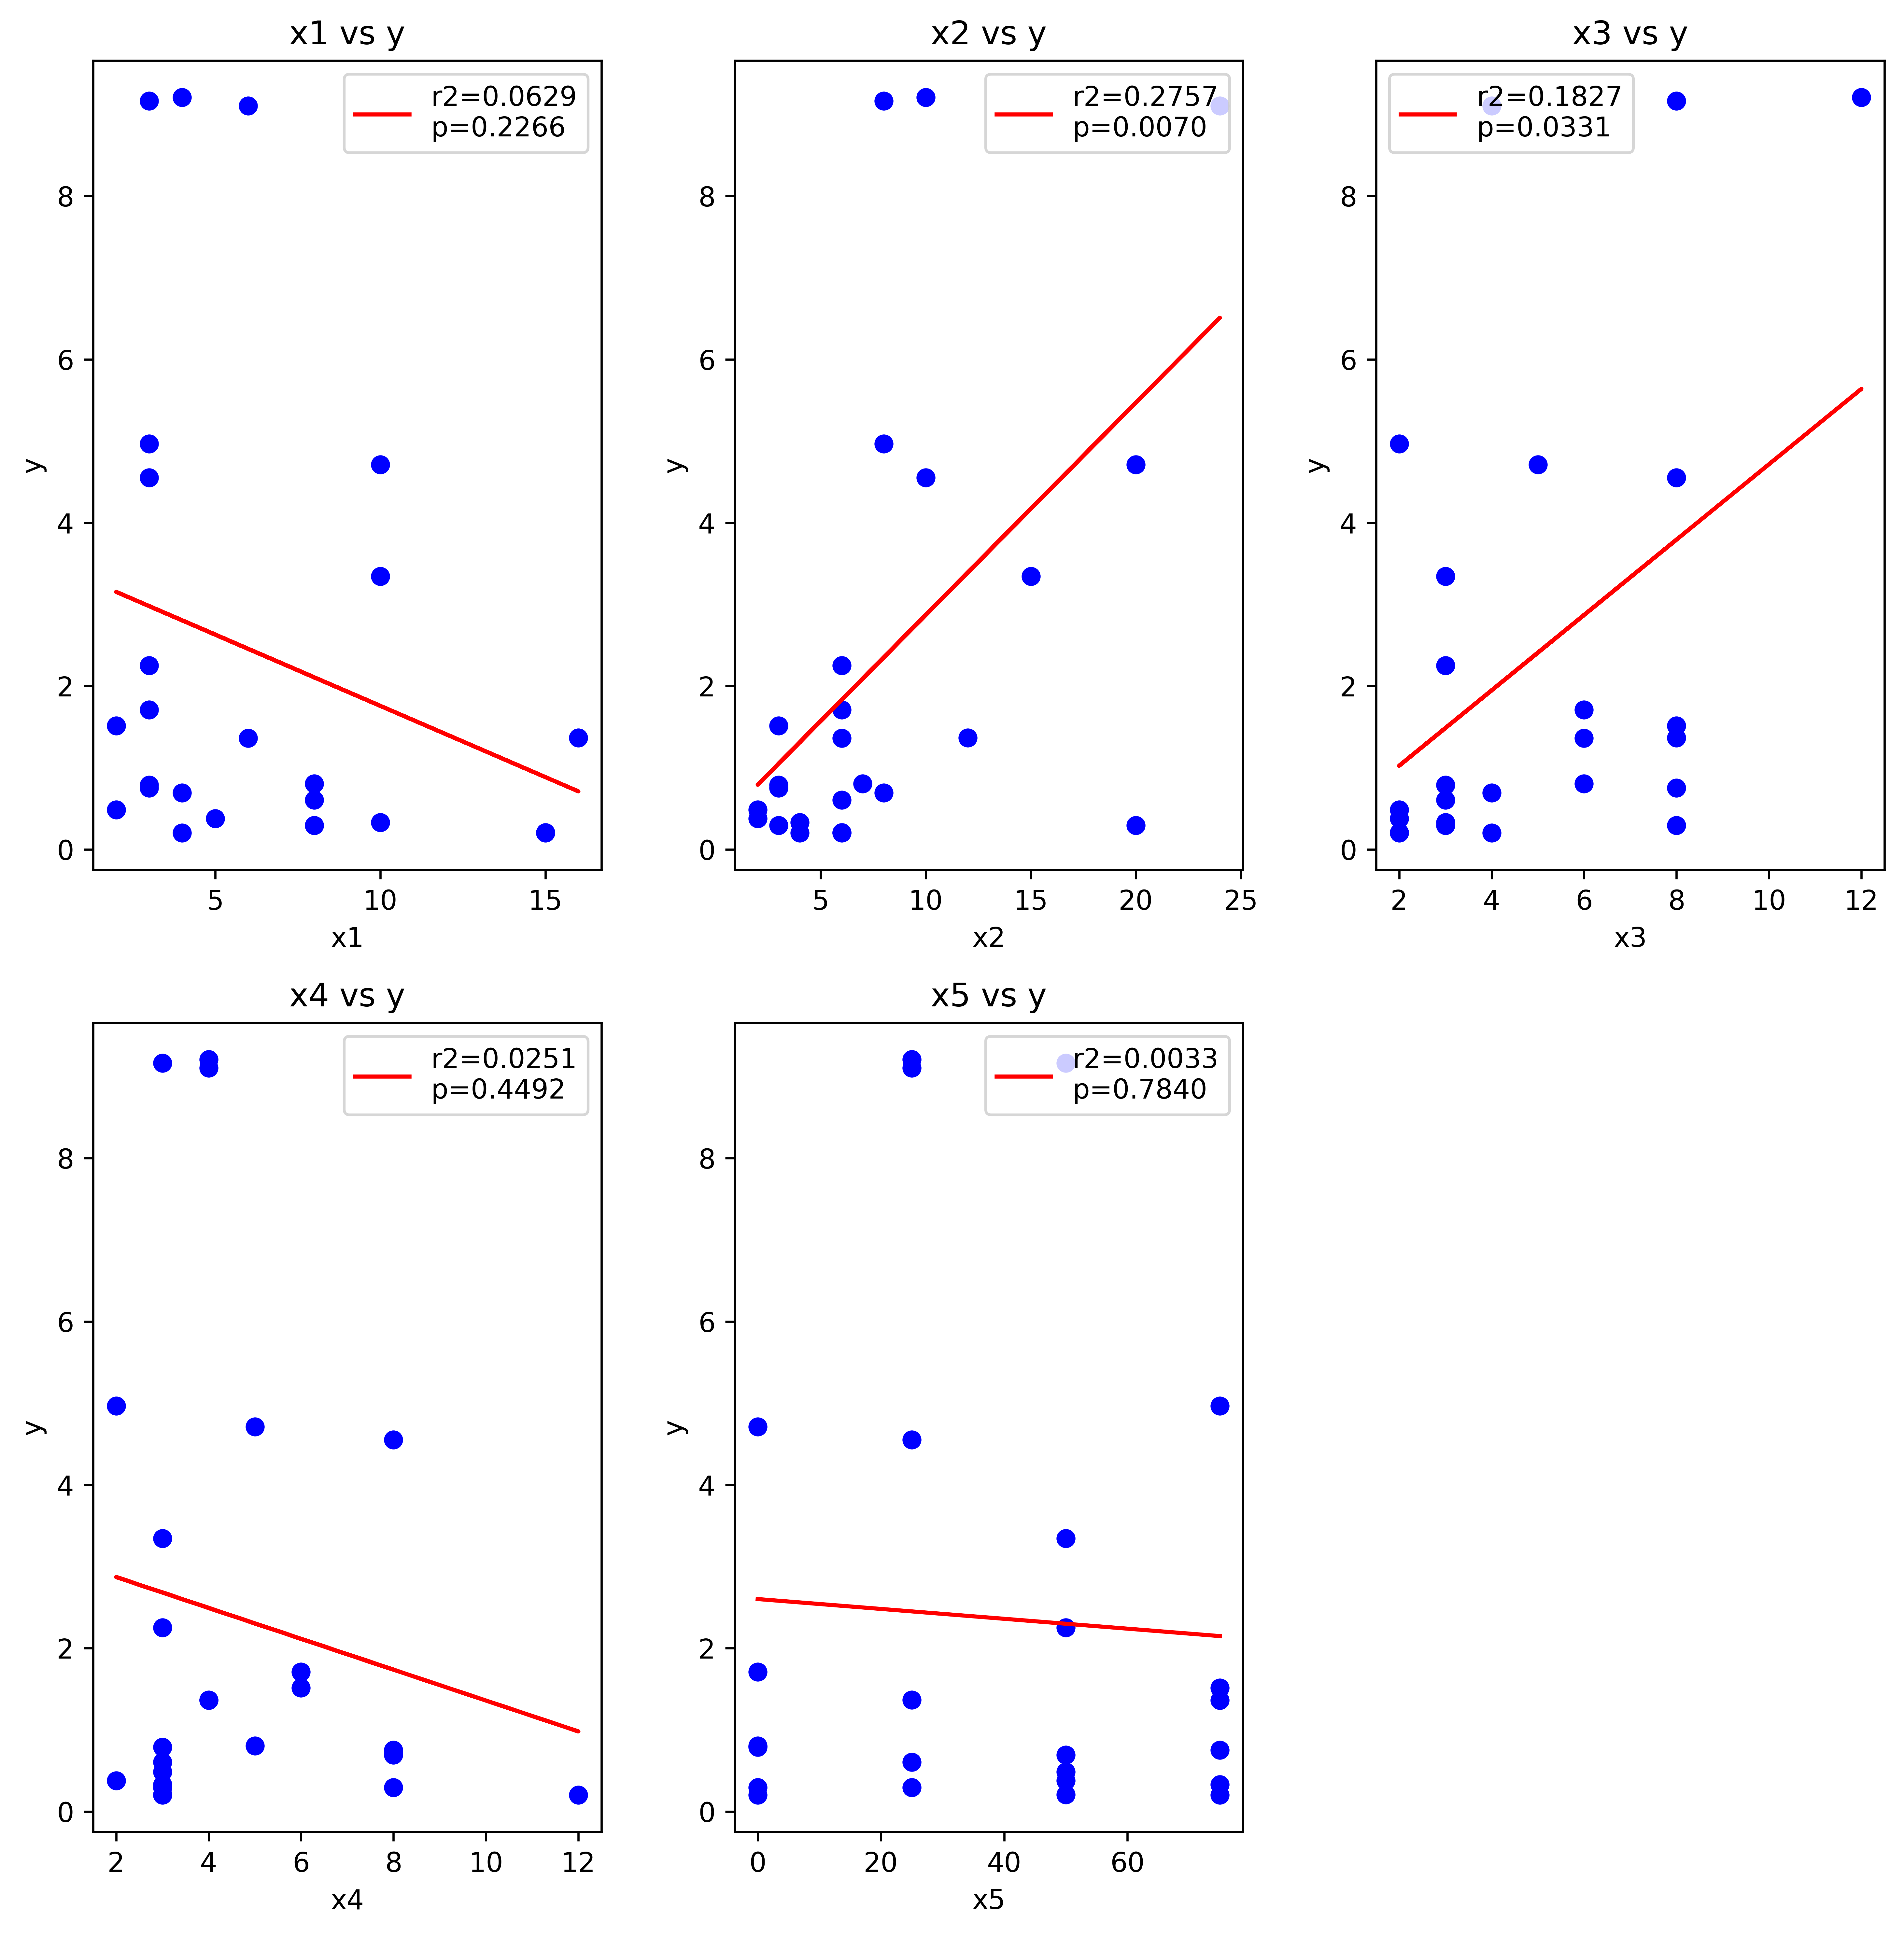

In [20]:
# descripción de los tratamientos
# relaciones
fig, ax = plt.subplots(2, 3, figsize=(10, 10), dpi=600)
ax = ax.flatten()
for i, col in enumerate(jet_df.columns[:-1]):
    slope, intercept, r_value, p_value, std_err = stats.linregress(jet_df[col], jet_df['y'])
    ax[i].scatter(jet_df[col], jet_df['y'], color='blue')
    ax[i].plot(jet_df[col], slope*jet_df[col] + intercept, color='red', label=f'r2={r_value**2:.4f}\np={p_value:.4f}')
    ax[i].set_title(f"{col} vs y")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('y')
    ax[i].legend()
ax[-1].axis('off')
plt.tight_layout()

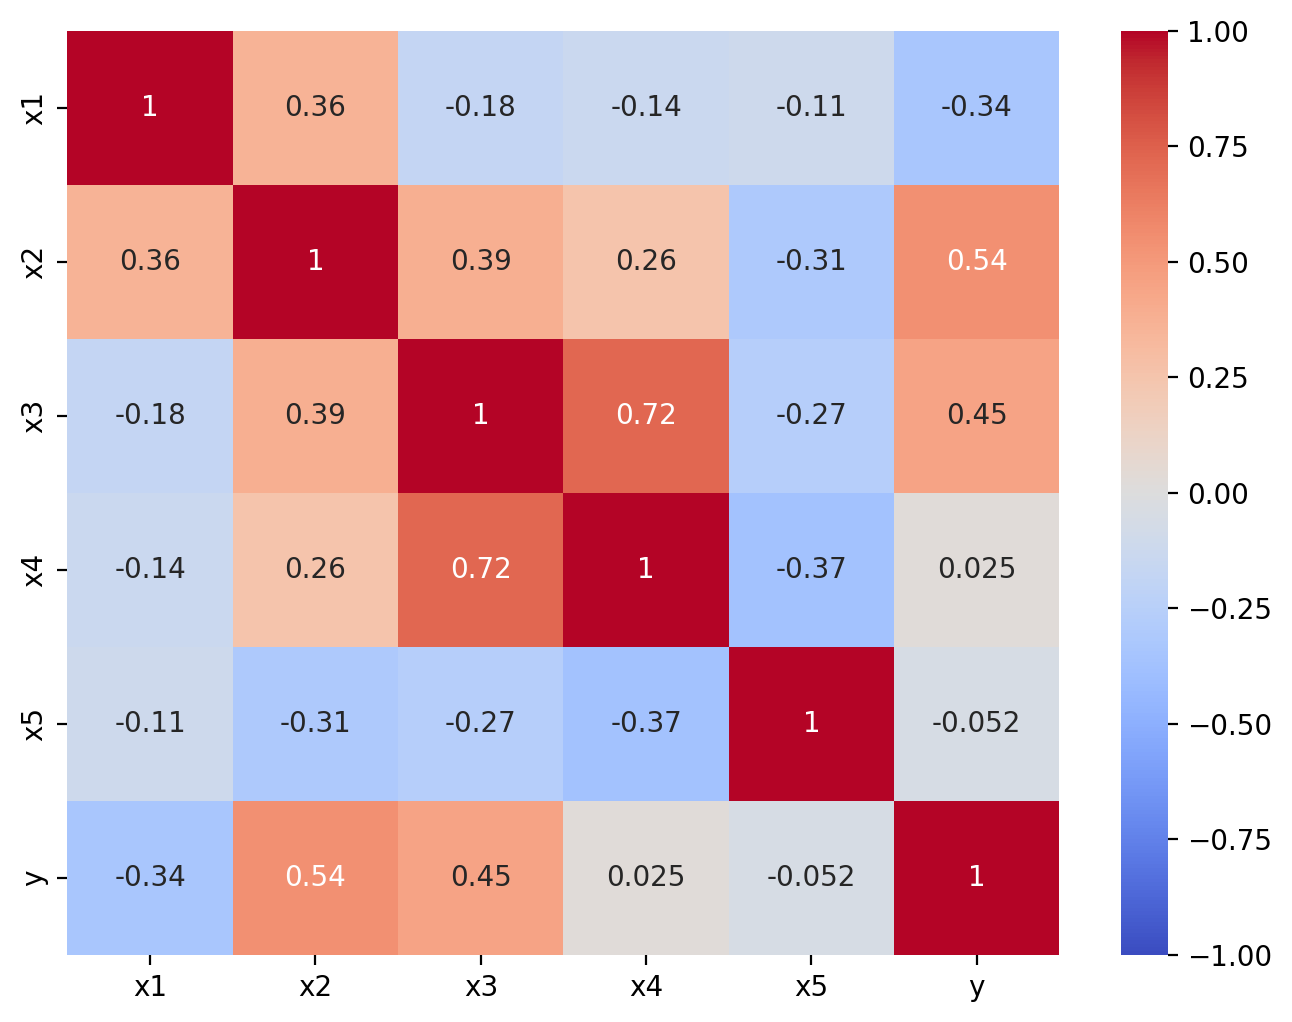

In [21]:
# analisis de correlacion
import seaborn as sns
correlation_matrix = jet_df.corr(method = 'spearman')
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
cax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=ax,
                   vmin=-1, vmax=1, center=0)


# b)
Construya un modelo nulo del impulso del motor (y). Reporte la ecuación del modelo, contraste con los datos experimentales y explique brevemente ¿Qué es y cuál es la utilidad de un modelo nulo? (2.5 puntos) 

In [22]:
null_model = ols('y ~ 1', data=jet_df).fit()
print(null_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 09 Jun 2026   Prob (F-statistic):                nan
Time:                        22:42:22   Log-Likelihood:                -61.921
No. Observations:                  25   AIC:                             125.8
Df Residuals:                      24   BIC:                             127.1
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3721      0.588      4.035      0.0

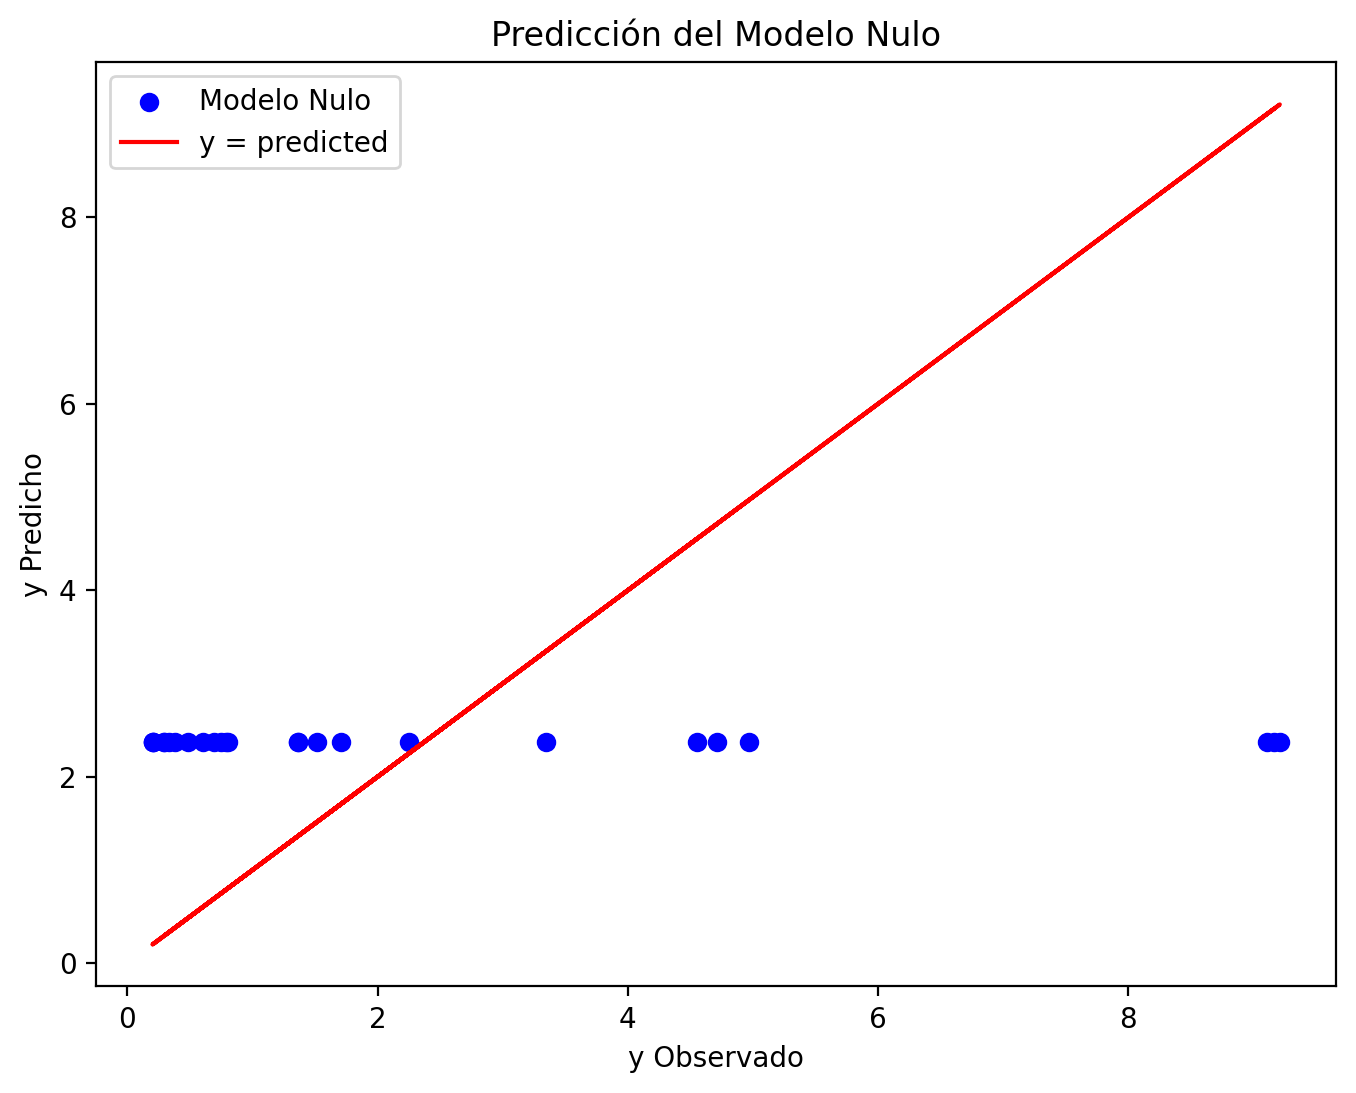

In [23]:
# plot
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
predicted = null_model.fittedvalues
ax.scatter(jet_df['y'], predicted, color='blue', label='Modelo Nulo')
ax.plot(jet_df['y'], jet_df['y'], color='red', label='y = predicted')
ax.set_xlabel('y Observado')
ax.set_ylabel('y Predicho')
ax.set_title('Predicción del Modelo Nulo')
ax.legend()


Text(0, 0.5, 'Residuos')

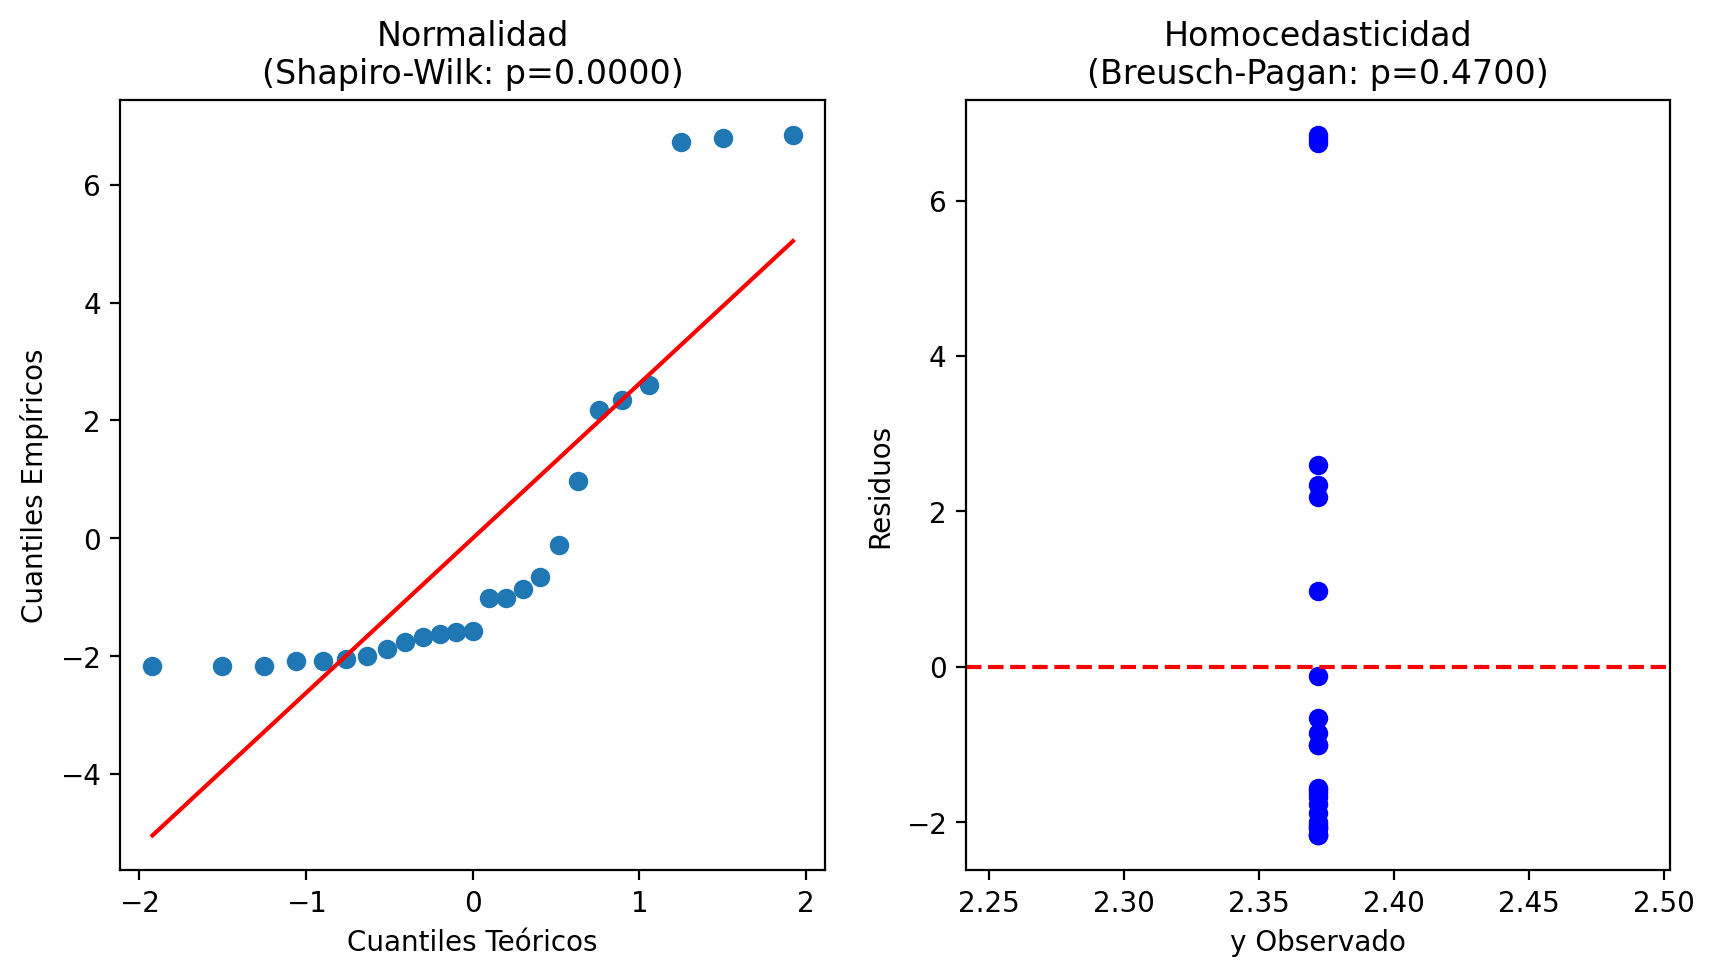

In [24]:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi=200)
redis = null_model.resid
# normalidad
(osm, osr), (slope, intercept, r) = stats.probplot(redis, dist='norm')
ax[0].scatter(osm, osr)
ax[0].plot(osm, slope*osm + intercept, color='red') 
shapiro_stat, shapiro_p = stats.shapiro(redis)
ax[0].set_title(f'Normalidad\n(Shapiro-Wilk: p={shapiro_p:.4f})')
ax[0].set_xlabel('Cuantiles Teóricos')
ax[0].set_ylabel('Cuantiles Empíricos')
# bp
lm, lm_p, fvalue, f_p = sm.stats.diagnostic.het_breuschpagan(resid, anova_model.model.exog)
ax[1].scatter(null_model.fittedvalues, redis, color='blue')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title(f'Homocedasticidad\n(Breusch-Pagan: p={lm_p:.4f})')
ax[1].set_xlabel('y Observado')
ax[1].set_ylabel('Residuos')


# c)
Construya un modelo de regresión lineal con todas las variables para un nivel de significancia α = 0.01. ¿Coincide con lo observado en 3b)? Se espera que reporten la estadística y el desempeño del modelo de regresión. 

In [25]:
jet_ols = ols('y ~ x1 + x2 + x3 + x4 + x5', data=jet_df).fit()
print("\nOLS Regression Summary:")
print(jet_ols.summary())


OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     8.155
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           0.000298
Time:                        22:42:22   Log-Likelihood:                -47.594
No. Observations:                  25   AIC:                             107.2
Df Residuals:                      19   BIC:                             114.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.0622      

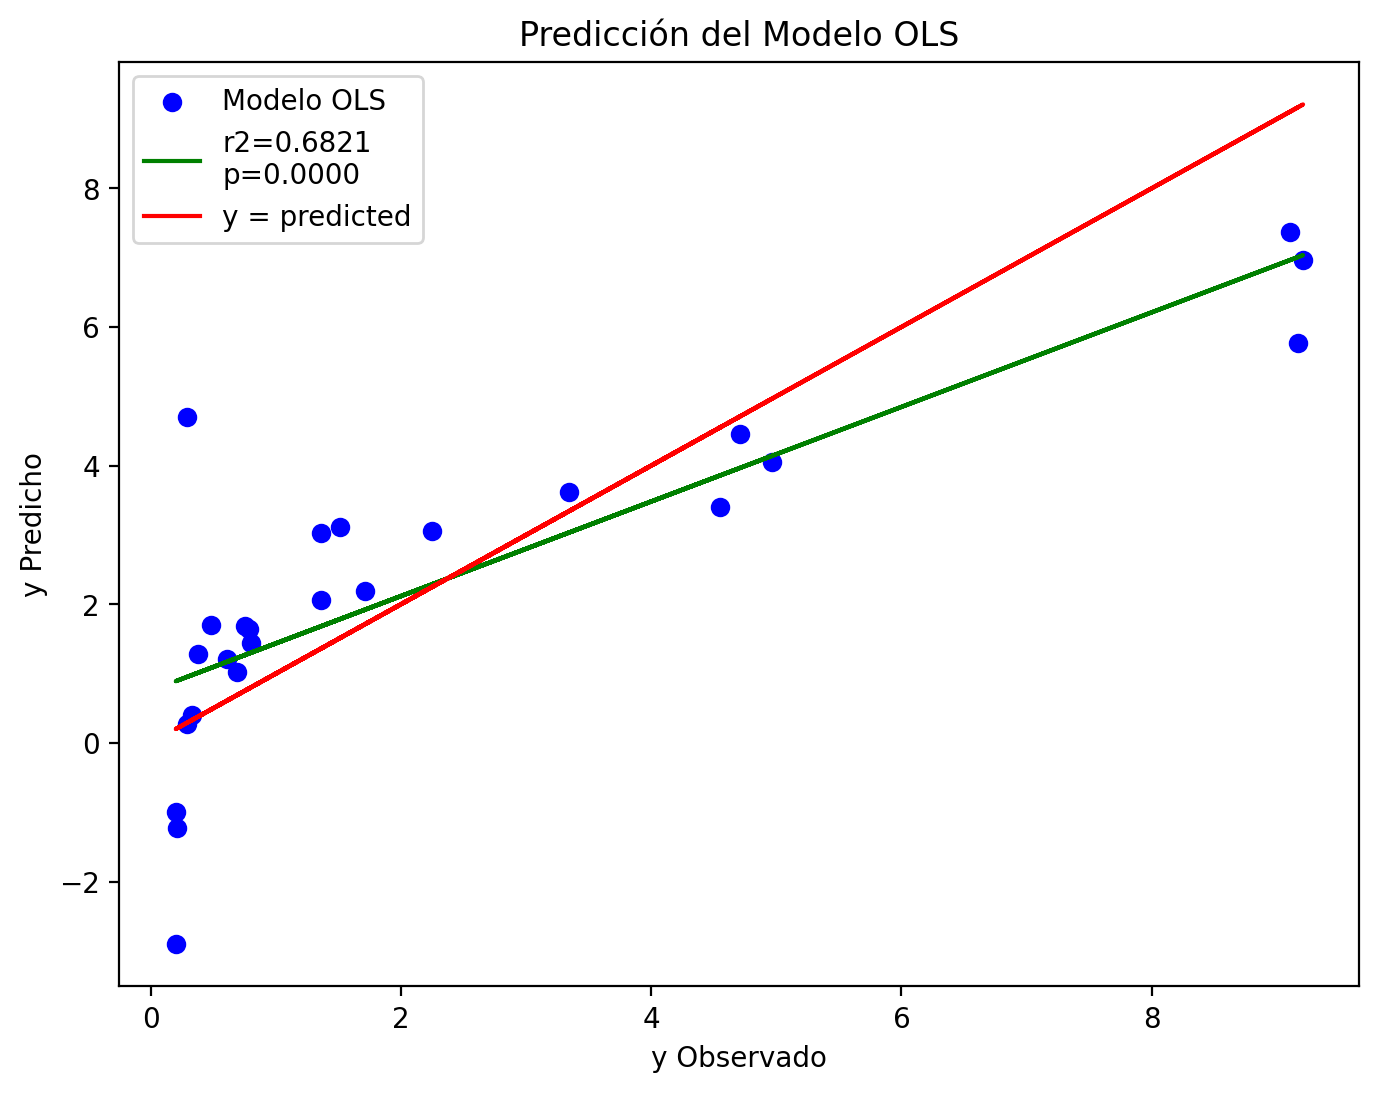

In [26]:
# desempeño del modelo
predicted_ols = jet_ols.fittedvalues
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
ax.scatter(jet_df['y'], predicted_ols, color='blue', label='Modelo OLS')
slope, intercept, r_value, p_value, std_err = stats.linregress(jet_df['y'], predicted_ols)
ax.plot(jet_df['y'], slope*jet_df['y'] + intercept, color='green', label=f'r2={r_value**2:.4f}\np={p_value:.4f}')
ax.plot(jet_df['y'], jet_df['y'], color='red', label='y = predicted')
ax.set_xlabel('y Observado')
ax.set_ylabel('y Predicho')
ax.set_title('Predicción del Modelo OLS')
ax.legend() 

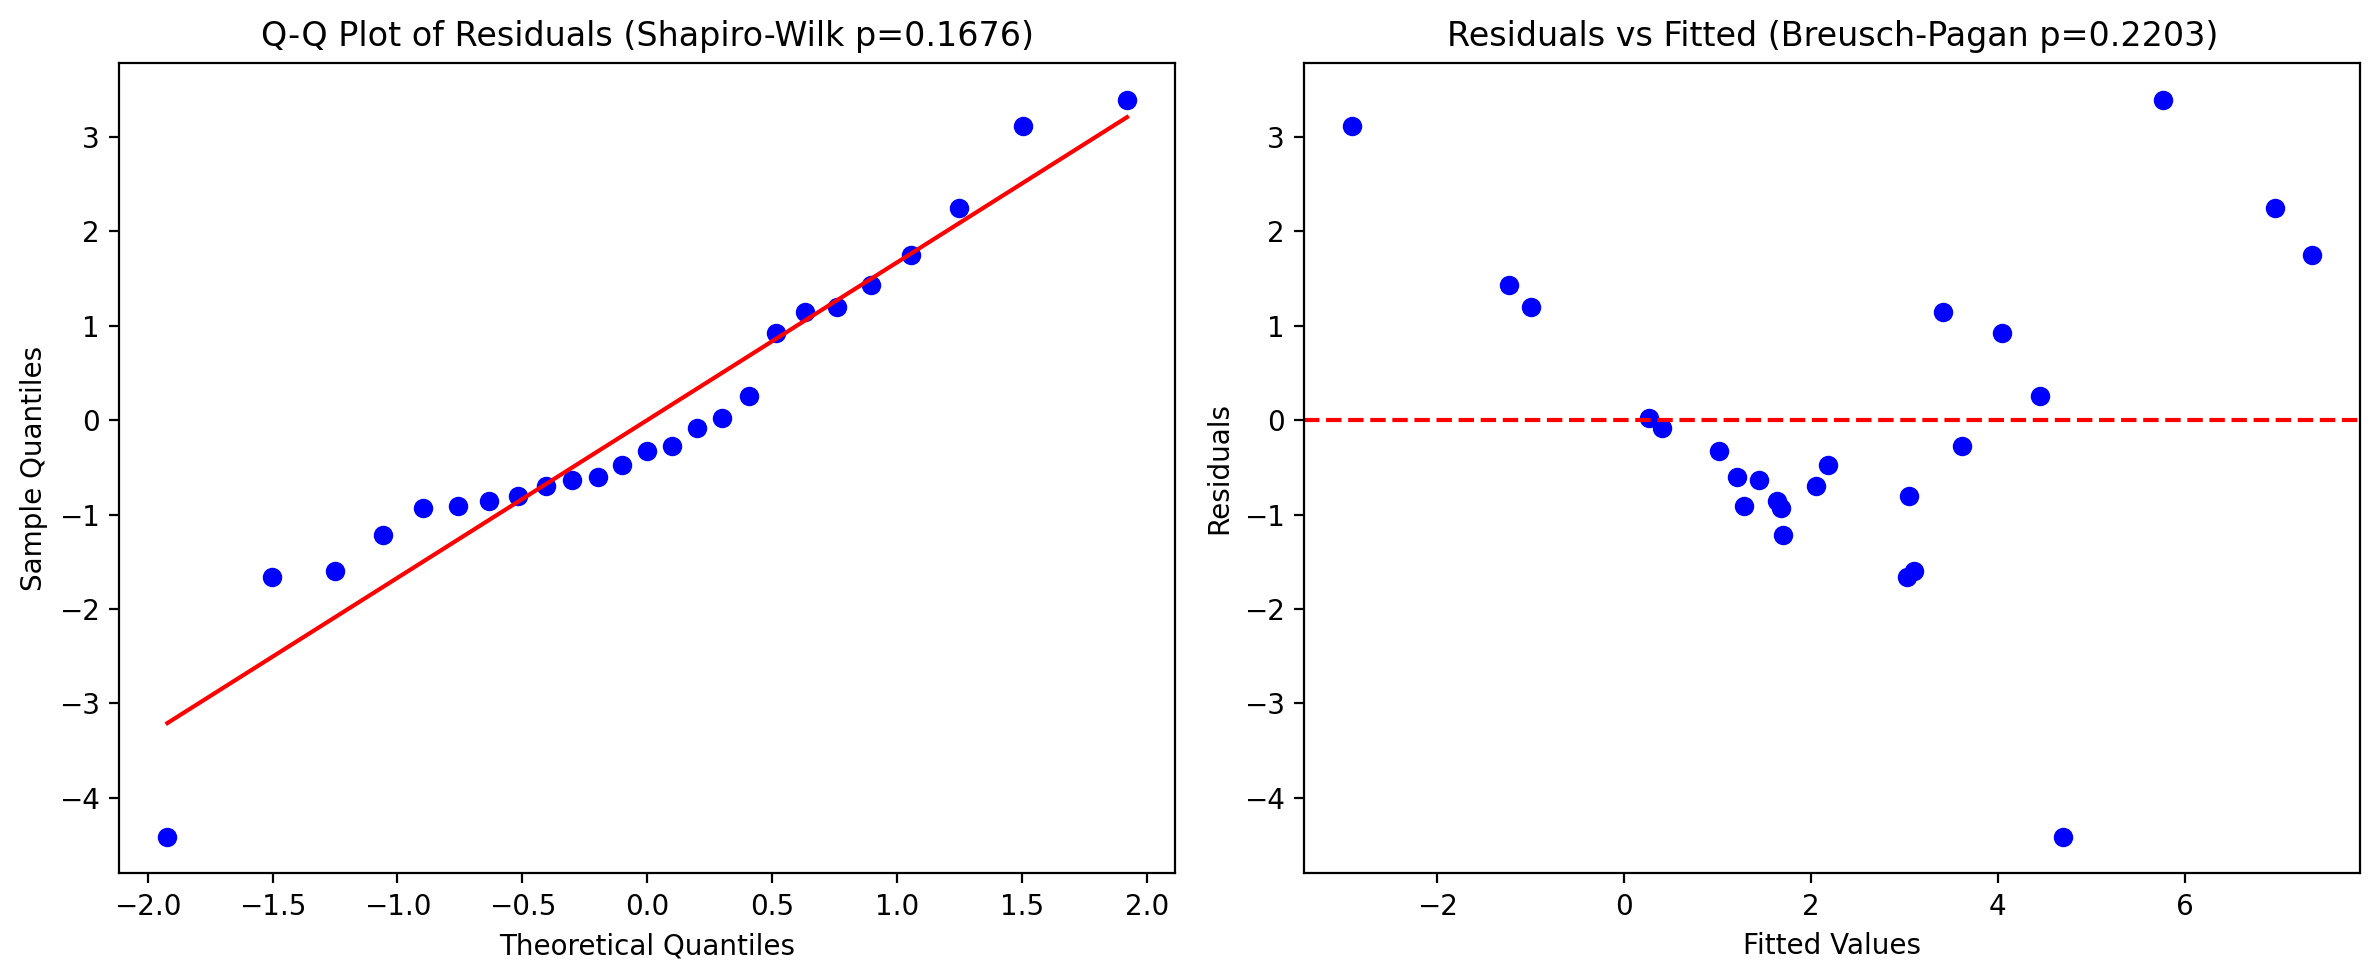

In [27]:
res_jet = jet_ols.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=200)

(osm, osr), (slope, intercept, r) = stats.probplot(res_jet, dist="norm")
ax[0].scatter(osm, osr, color="blue")
ax[0].plot(osm, slope * osm + intercept, color="red")
ax[0].set_xlabel("Theoretical Quantiles")
ax[0].set_ylabel("Sample Quantiles")
ax[0].set_title("Q-Q Plot of Residuals")

shapiro_result = stats.shapiro(res_jet)
ax[0].set_title(f"Q-Q Plot of Residuals (Shapiro-Wilk p={shapiro_result.pvalue:.4f})")
ax[1].scatter(jet_ols.fittedvalues, res_jet, color="blue")
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_xlabel("Fitted Values")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residuals vs Fitted")

bp_test = sm.stats.diagnostic.het_breuschpagan(res_jet, jet_ols.model.exog)
ax[1].set_title(f"Residuals vs Fitted (Breusch-Pagan p={bp_test[1]:.4f})")
plt.tight_layout()
plt.show()


# d)
¿Es posible mejorar el modelo? Si es así, haga una selección de variables. Reporte nuevamente la estadística y desempeño del modelo mejorado. 


Reduced OLS Regression Summary (without x5):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     10.43
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           9.92e-05
Time:                        22:50:40   Log-Likelihood:                -47.837
No. Observations:                  25   AIC:                             105.7
Df Residuals:                      20   BIC:                             111.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

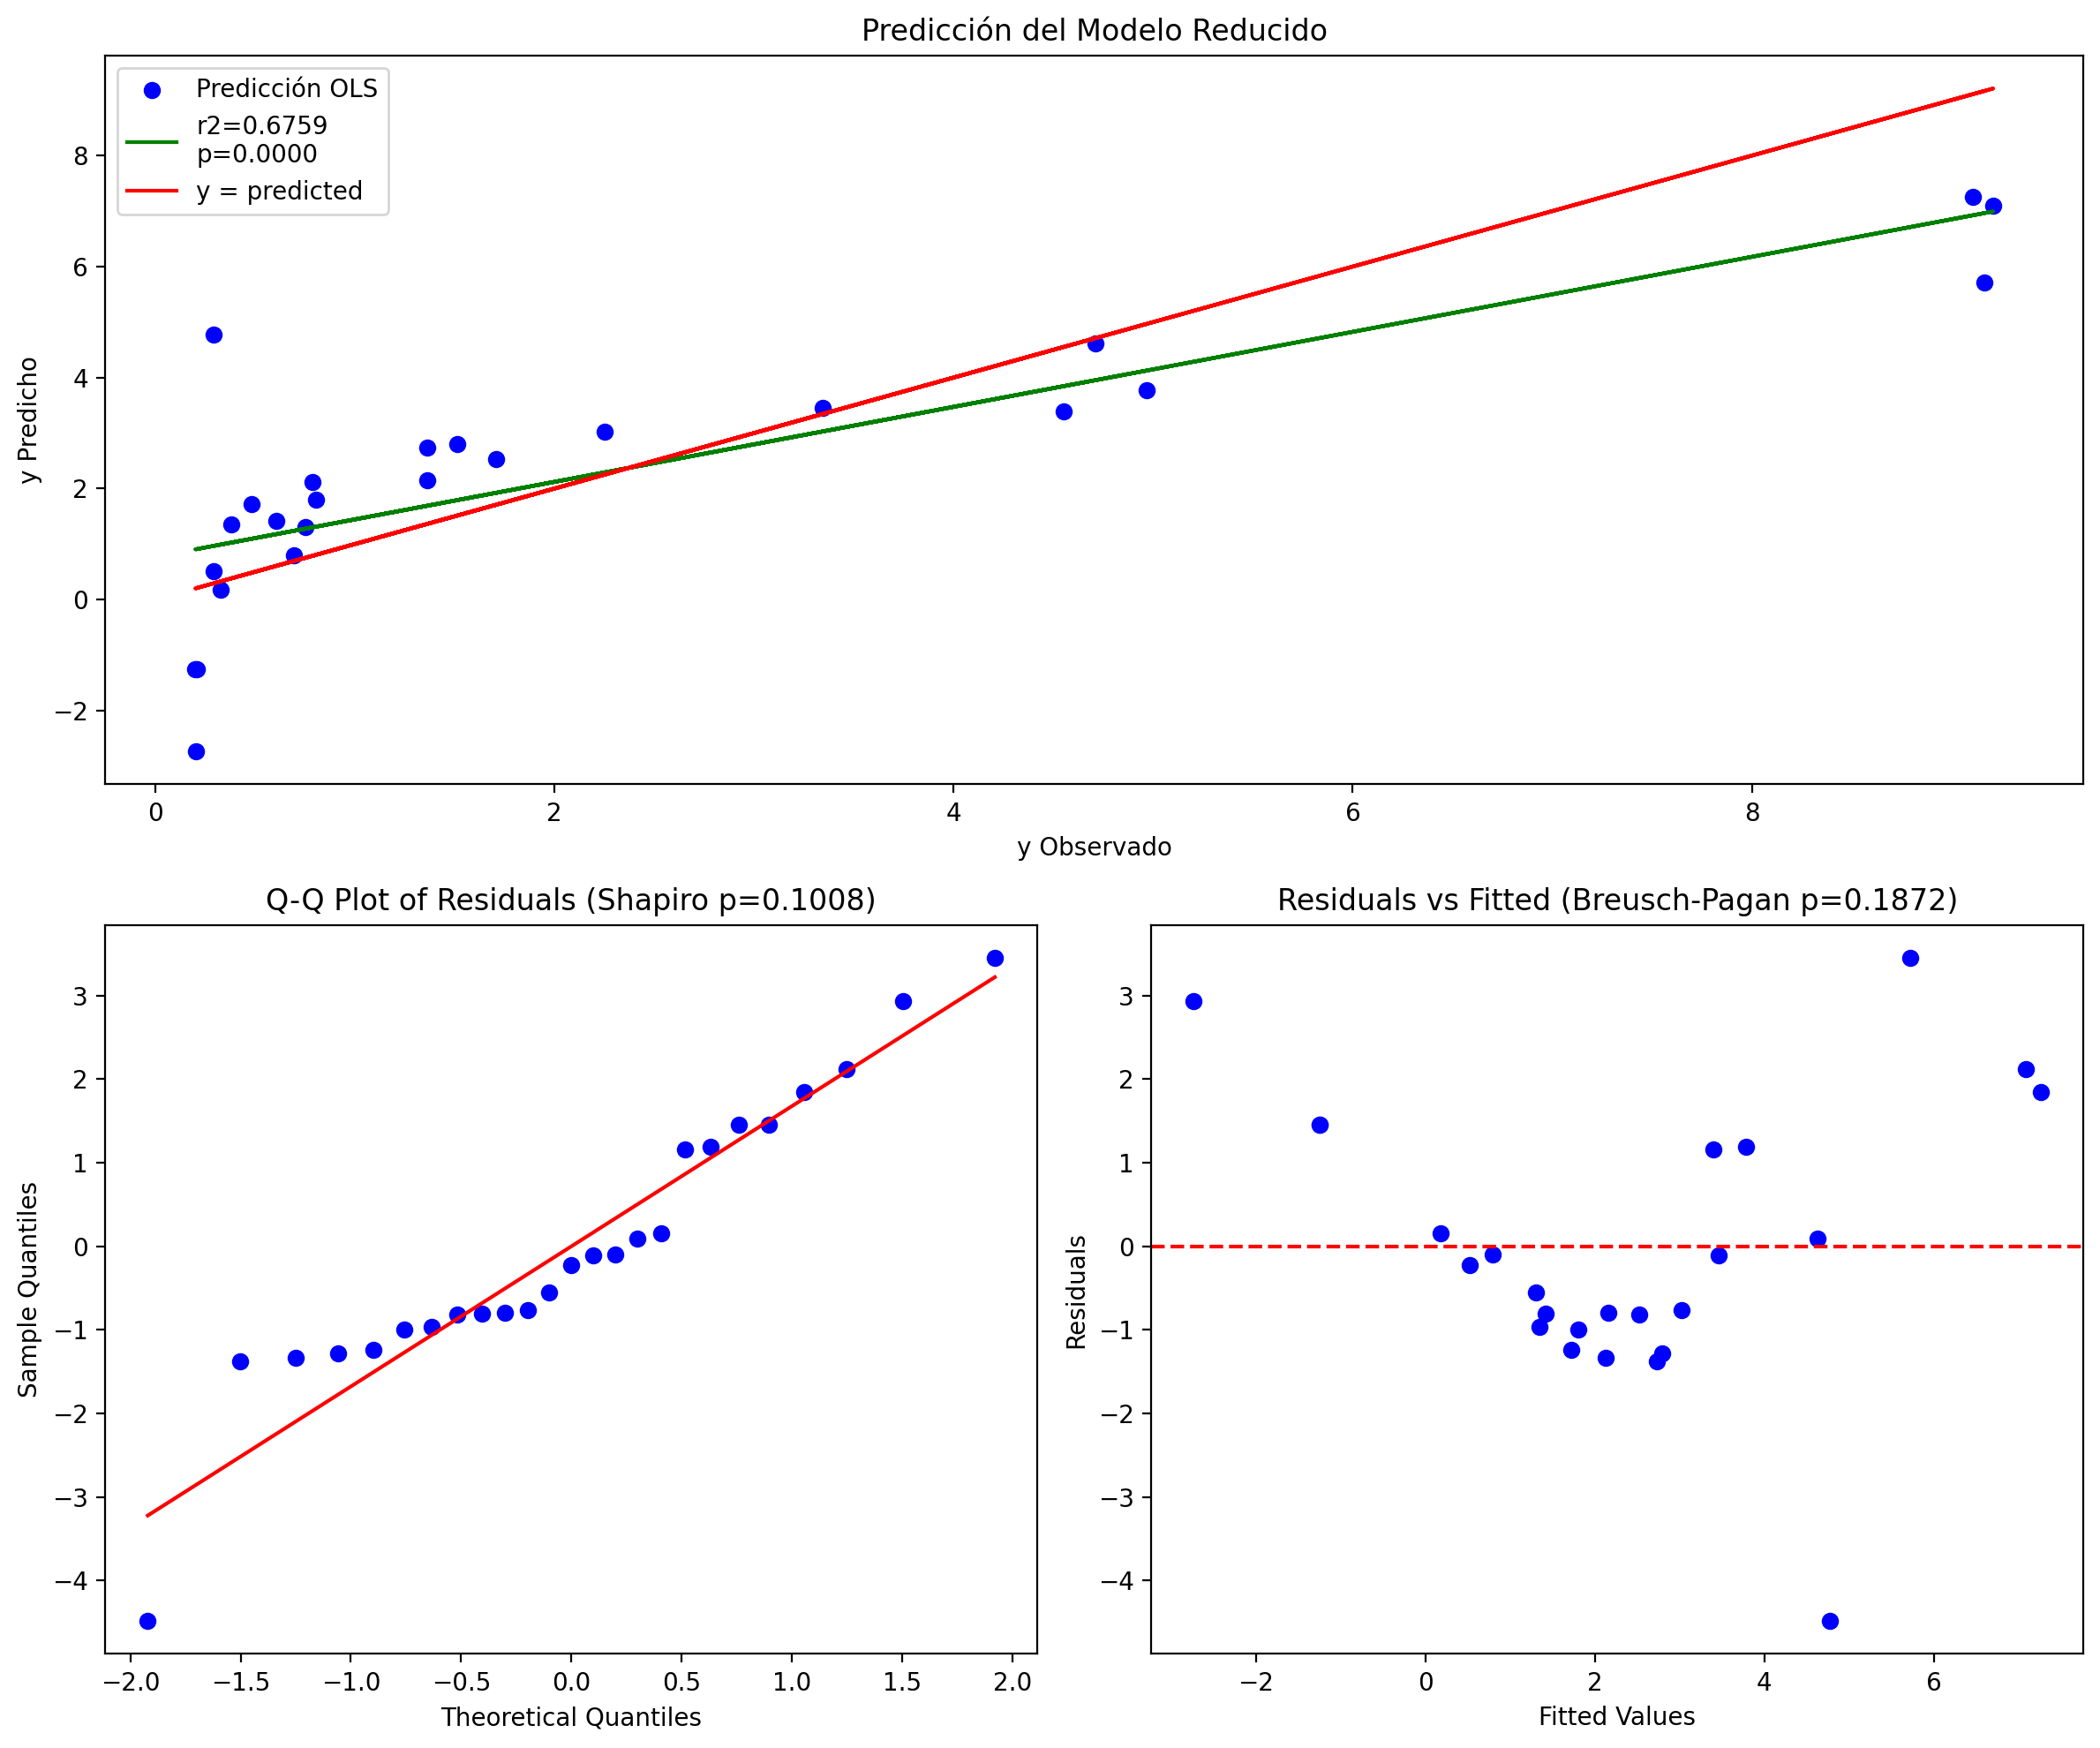


Shapiro-Wilk Test Result (Reduced Model):
Statistic: 0.9328, p-value: 1.0075e-01

Breusch-Pagan Test Result (Reduced Model):
Lagrange Multiplier Statistic: 6.1640, p-value: 1.8723e-01


In [34]:
# x5 pval > 0.01
jet_red1 = ols('y ~ x1 + x2 + x3 + x4', data=jet_df).fit()
print("\nReduced OLS Regression Summary (without x5):")
print(jet_red1.summary())

# Verificacion de supuestos del modelo reducido y ajuste
res_red1 = jet_red1.resid

fig, ax = plt.subplot_mosaic([
    ['ajuste', 'ajuste'],
    ['qq', 'resid']
], figsize=(12, 10), dpi=200)

# Gráfico de Ajuste 
ax['ajuste'].scatter(jet_df['y'], jet_red1.fittedvalues, color='blue', label='Predicción OLS')
slope, intercept, r_value, p_value, std_err = stats.linregress(jet_df['y'], jet_red1.fittedvalues)
ax['ajuste'].plot(jet_df['y'], slope * jet_df['y'] + intercept, color='green', label=f'r2={r_value**2:.4f}\np={p_value:.4f}')
ax['ajuste'].plot(jet_df['y'], jet_df['y'], color='red', label='y = predicted')
ax['ajuste'].set_xlabel('y Observado')
ax['ajuste'].set_ylabel('y Predicho')
ax['ajuste'].set_title('Predicción del Modelo Reducido')
ax['ajuste'].legend()

# Q-Q Plot con Shapiro-Wilk 
(osm, osr), (slope_qq, intercept_qq, r) = stats.probplot(res_red1, dist="norm")
ax['qq'].scatter(osm, osr, color='blue')
ax['qq'].plot(osm, slope_qq * osm + intercept_qq, 'r')
ax['qq'].set_xlabel('Theoretical Quantiles')
ax['qq'].set_ylabel('Sample Quantiles')
shapiro_result_red1 = stats.shapiro(res_red1)
ax['qq'].set_title(f'Q-Q Plot of Residuals (Shapiro p={shapiro_result_red1.pvalue:.4f})')

# Residuals vs Fitted con Breusch-Pagan
ax['resid'].scatter(jet_red1.fittedvalues, res_red1, color='blue')
ax['resid'].axhline(0, color='red', linestyle='--')
ax['resid'].set_xlabel('Fitted Values')
ax['resid'].set_ylabel('Residuals')
bp_test_red1 = sm.stats.diagnostic.het_breuschpagan(res_red1, jet_red1.model.exog)
ax['resid'].set_title(f'Residuals vs Fitted (Breusch-Pagan p={bp_test_red1[1]:.4f})')

plt.tight_layout()
plt.show()

# Tests formales adicionales
print("\nShapiro-Wilk Test Result (Reduced Model):")
print(f"Statistic: {shapiro_result_red1.statistic:.4f}, p-value: {shapiro_result_red1.pvalue:.4e}")

print("\nBreusch-Pagan Test Result (Reduced Model):")
print(f"Lagrange Multiplier Statistic: {bp_test_red1[0]:.4f}, p-value: {bp_test_red1[1]:.4e}")

Podemos eliminar x3 (p>0.01)


Reduced OLS Regression Summary (without x5):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     8.867
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           0.000542
Time:                        22:50:41   Log-Likelihood:                -51.692
No. Observations:                  25   AIC:                             111.4
Df Residuals:                      21   BIC:                             116.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

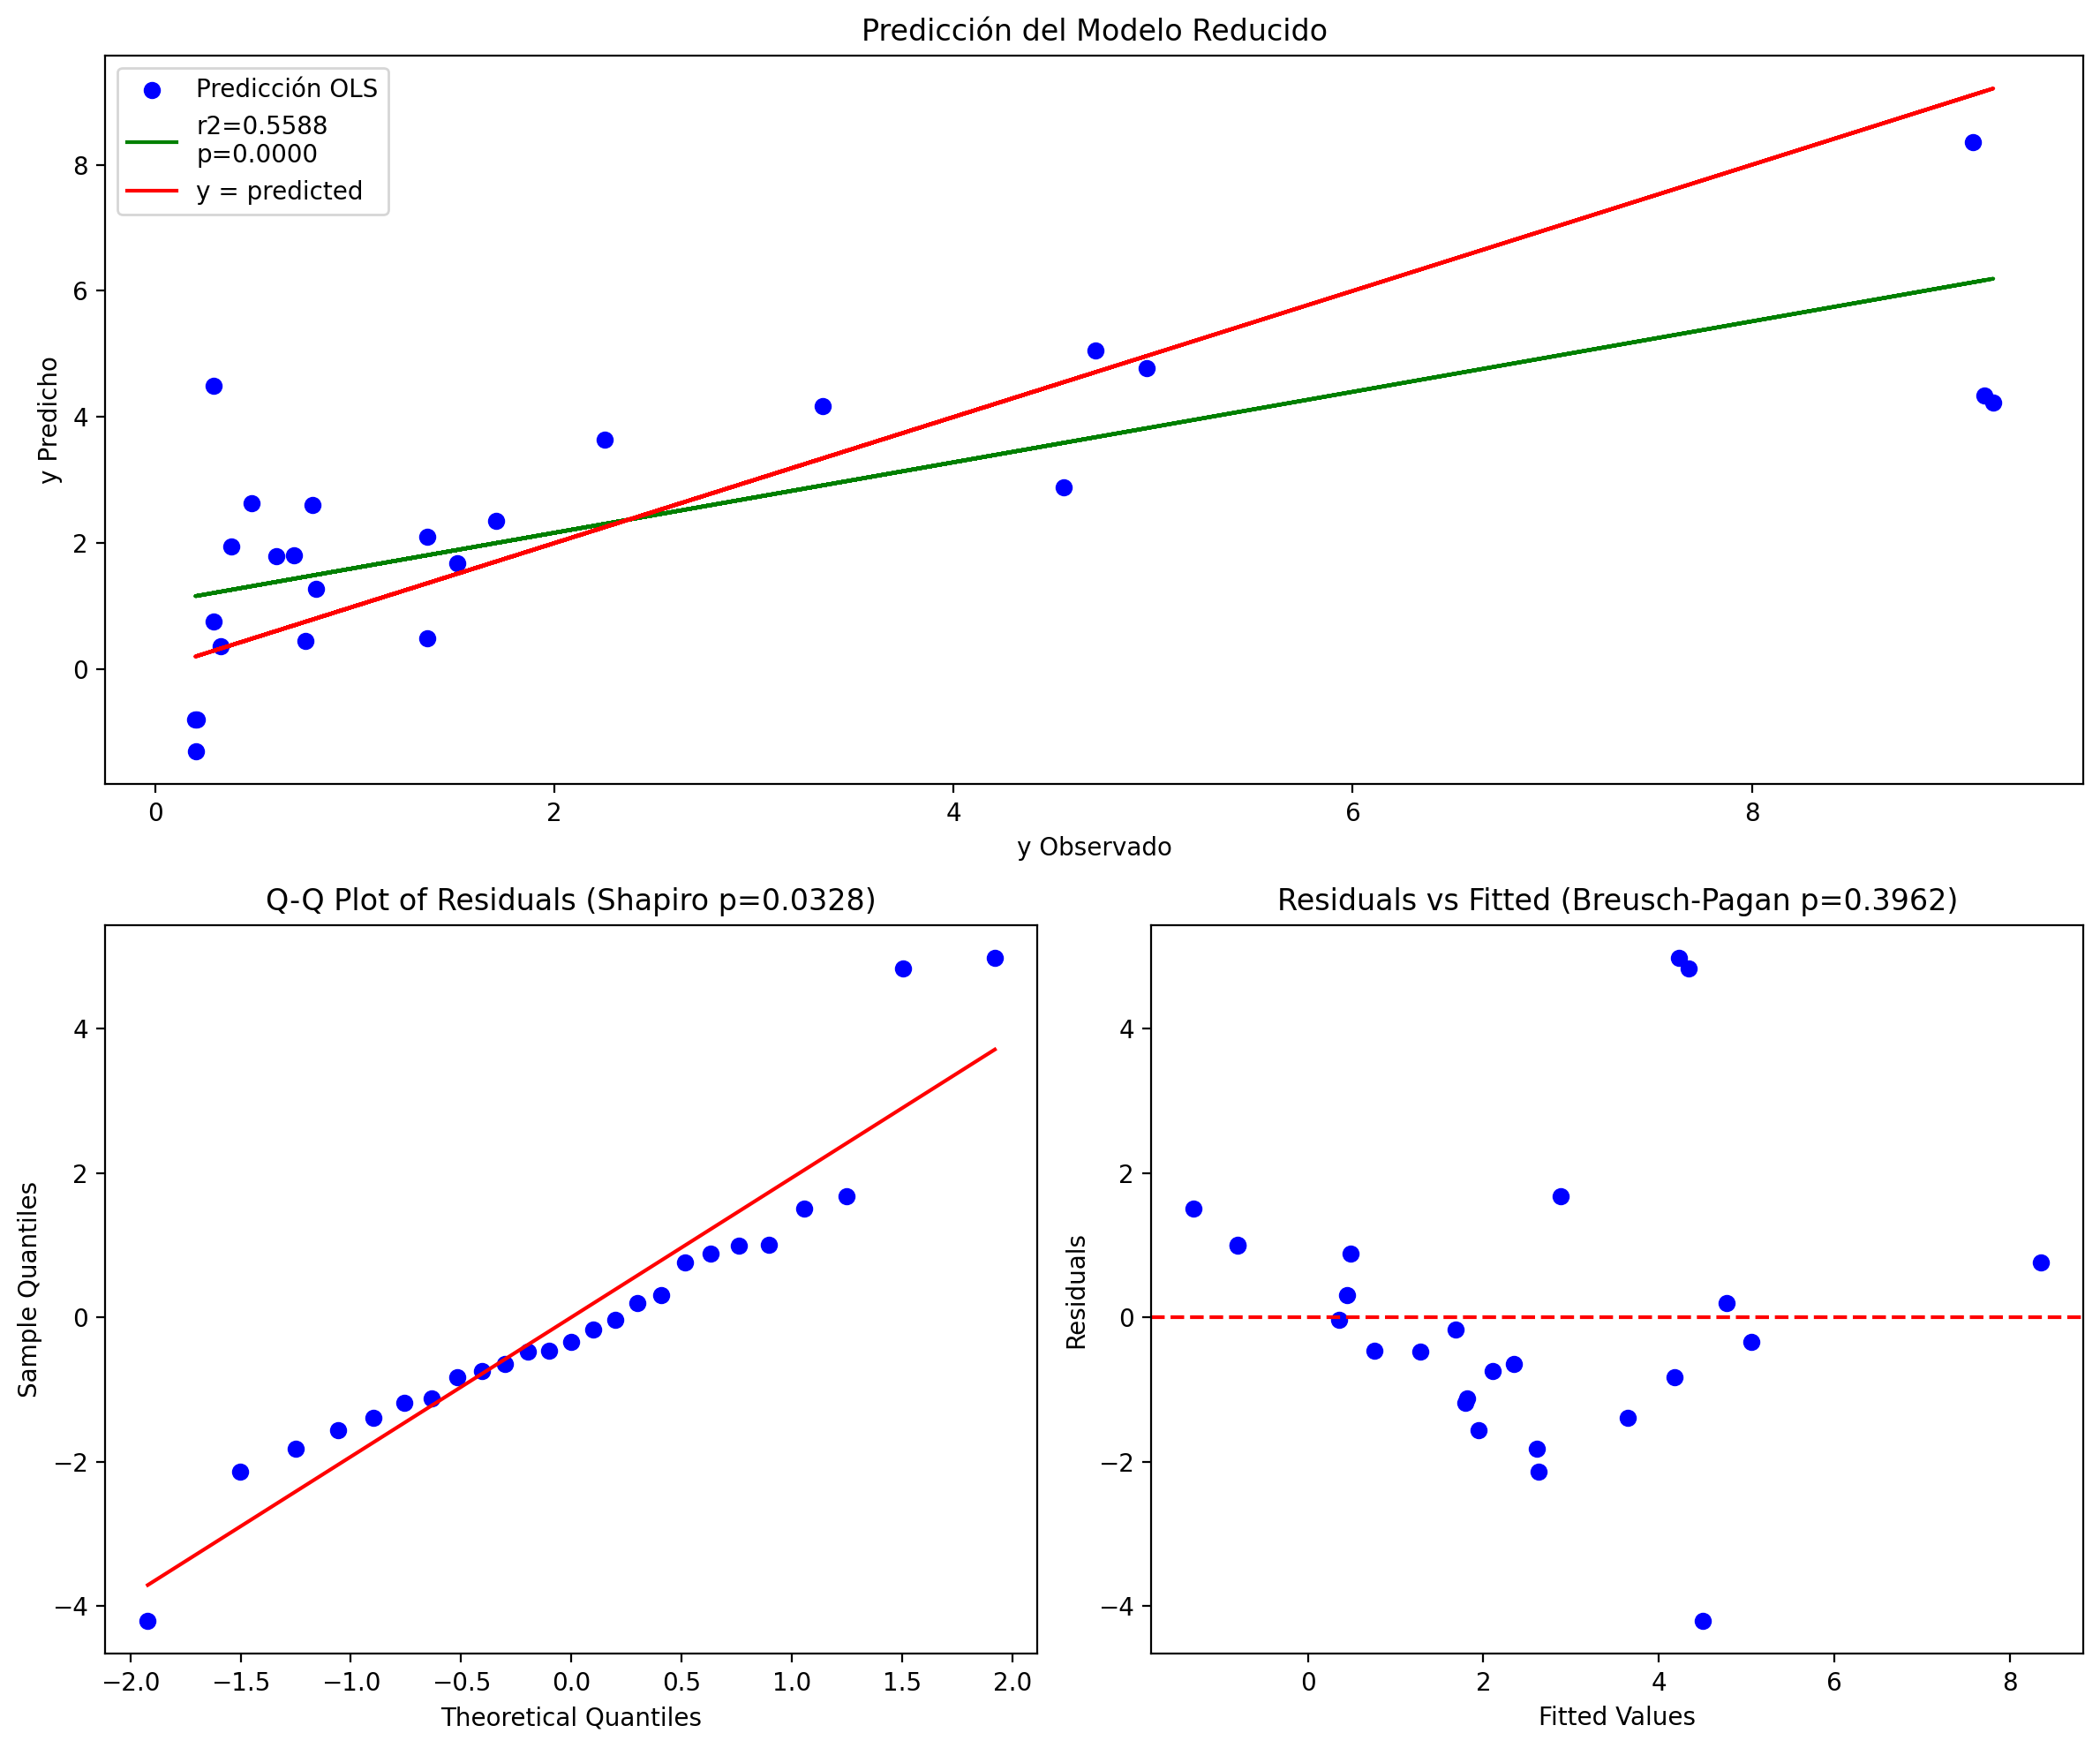


Shapiro-Wilk Test Result (Reduced Model):
Statistic: 0.9115, p-value: 3.2849e-02

Breusch-Pagan Test Result (Reduced Model):
Lagrange Multiplier Statistic: 2.9704, p-value: 3.9621e-01


In [35]:
# x5 pval > 0.01
jet_red2 = ols('y ~ x1 + x2 + x4', data=jet_df).fit()
print("\nReduced OLS Regression Summary (without x5):")
print(jet_red2.summary())

# Verificacion de supuestos del modelo reducido y ajuste
res_red2 = jet_red2.resid

fig, ax = plt.subplot_mosaic([
    ['ajuste', 'ajuste'],
    ['qq', 'resid']
], figsize=(12, 10), dpi=200)

# Gráfico de Ajuste 
ax['ajuste'].scatter(jet_df['y'], jet_red2.fittedvalues, color='blue', label='Predicción OLS')
slope, intercept, r_value, p_value, std_err = stats.linregress(jet_df['y'], jet_red2.fittedvalues)
ax['ajuste'].plot(jet_df['y'], slope * jet_df['y'] + intercept, color='green', label=f'r2={r_value**2:.4f}\np={p_value:.4f}')
ax['ajuste'].plot(jet_df['y'], jet_df['y'], color='red', label='y = predicted')
ax['ajuste'].set_xlabel('y Observado')
ax['ajuste'].set_ylabel('y Predicho')
ax['ajuste'].set_title('Predicción del Modelo Reducido')
ax['ajuste'].legend()

# Q-Q Plot con Shapiro-Wilk 
(osm, osr), (slope_qq, intercept_qq, r) = stats.probplot(res_red2, dist="norm")
ax['qq'].scatter(osm, osr, color='blue')
ax['qq'].plot(osm, slope_qq * osm + intercept_qq, 'r')
ax['qq'].set_xlabel('Theoretical Quantiles')
ax['qq'].set_ylabel('Sample Quantiles')
shapiro_result_red2 = stats.shapiro(res_red2)
ax['qq'].set_title(f'Q-Q Plot of Residuals (Shapiro p={shapiro_result_red2.pvalue:.4f})')

# Residuals vs Fitted con Breusch-Pagan 
ax['resid'].scatter(jet_red2.fittedvalues, res_red2, color='blue')
ax['resid'].axhline(0, color='red', linestyle='--')
ax['resid'].set_xlabel('Fitted Values')
ax['resid'].set_ylabel('Residuals')
bp_test_red2 = sm.stats.diagnostic.het_breuschpagan(res_red2, jet_red2.model.exog)
ax['resid'].set_title(f'Residuals vs Fitted (Breusch-Pagan p={bp_test_red2[1]:.4f})')

plt.tight_layout()
plt.show()

# Tests formales adicionales
print("\nShapiro-Wilk Test Result (Reduced Model):")
print(f"Statistic: {shapiro_result_red2.statistic:.4f}, p-value: {shapiro_result_red2.pvalue:.4e}")

print("\nBreusch-Pagan Test Result (Reduced Model):")
print(f"Lagrange Multiplier Statistic: {bp_test_red2[0]:.4f}, p-value: {bp_test_red2[1]:.4e}")
# Test de heterocedasticidad de White para el modelo reducido

El r^2 disminuye, así que nos quedamos con el modelo $ y \sim x_1 + x_2 + x_3 + x_4$

## e)

Compare el modelo de 3d) con el nulo. ¿Es este modelo superior al modelo nulo? Explique

Si. Justificar ya sea por r^2 o mse de la predicción.

In [36]:
print('R2_adj modelo reducido:',jet_red1.rsquared_adj)
print('R2_adj modelo nulo:',null_model.rsquared_adj)

R2_adj modelo reducido: 0.6110840715886399
R2_adj modelo nulo: 0.0


## f)

Realice una transformación logarítmica (log10) de la variable respuesta y las variables explicativas salvo x5 (elimine esta variable). Construya nuevamente un modelo de regresión y reporte la estadística y desempeño del nuevo modelo. Vuelva verificar las condiciones de regresión. ¿La transformación mejoró las condiciones y desempeño del modelo desarrollado en 3d)?



In [64]:
jet_log = jet_df.copy()
jet_log.drop(columns=['x5'], inplace=True) # eliminamos x5
jet_log = np.log10(jet_log)  # aplicamos logaritmo

jet_log_ols = ols('y ~ x1 + x2 + x3 + x4', data=jet_log).fit()
print("\nLog-Transformed OLS Regression Summary:")
print(jet_log_ols.summary())    


Log-Transformed OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     28.93
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           4.59e-08
Time:                        23:35:30   Log-Likelihood:                 4.0166
No. Observations:                  25   AIC:                             1.967
Df Residuals:                      20   BIC:                             8.061
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  

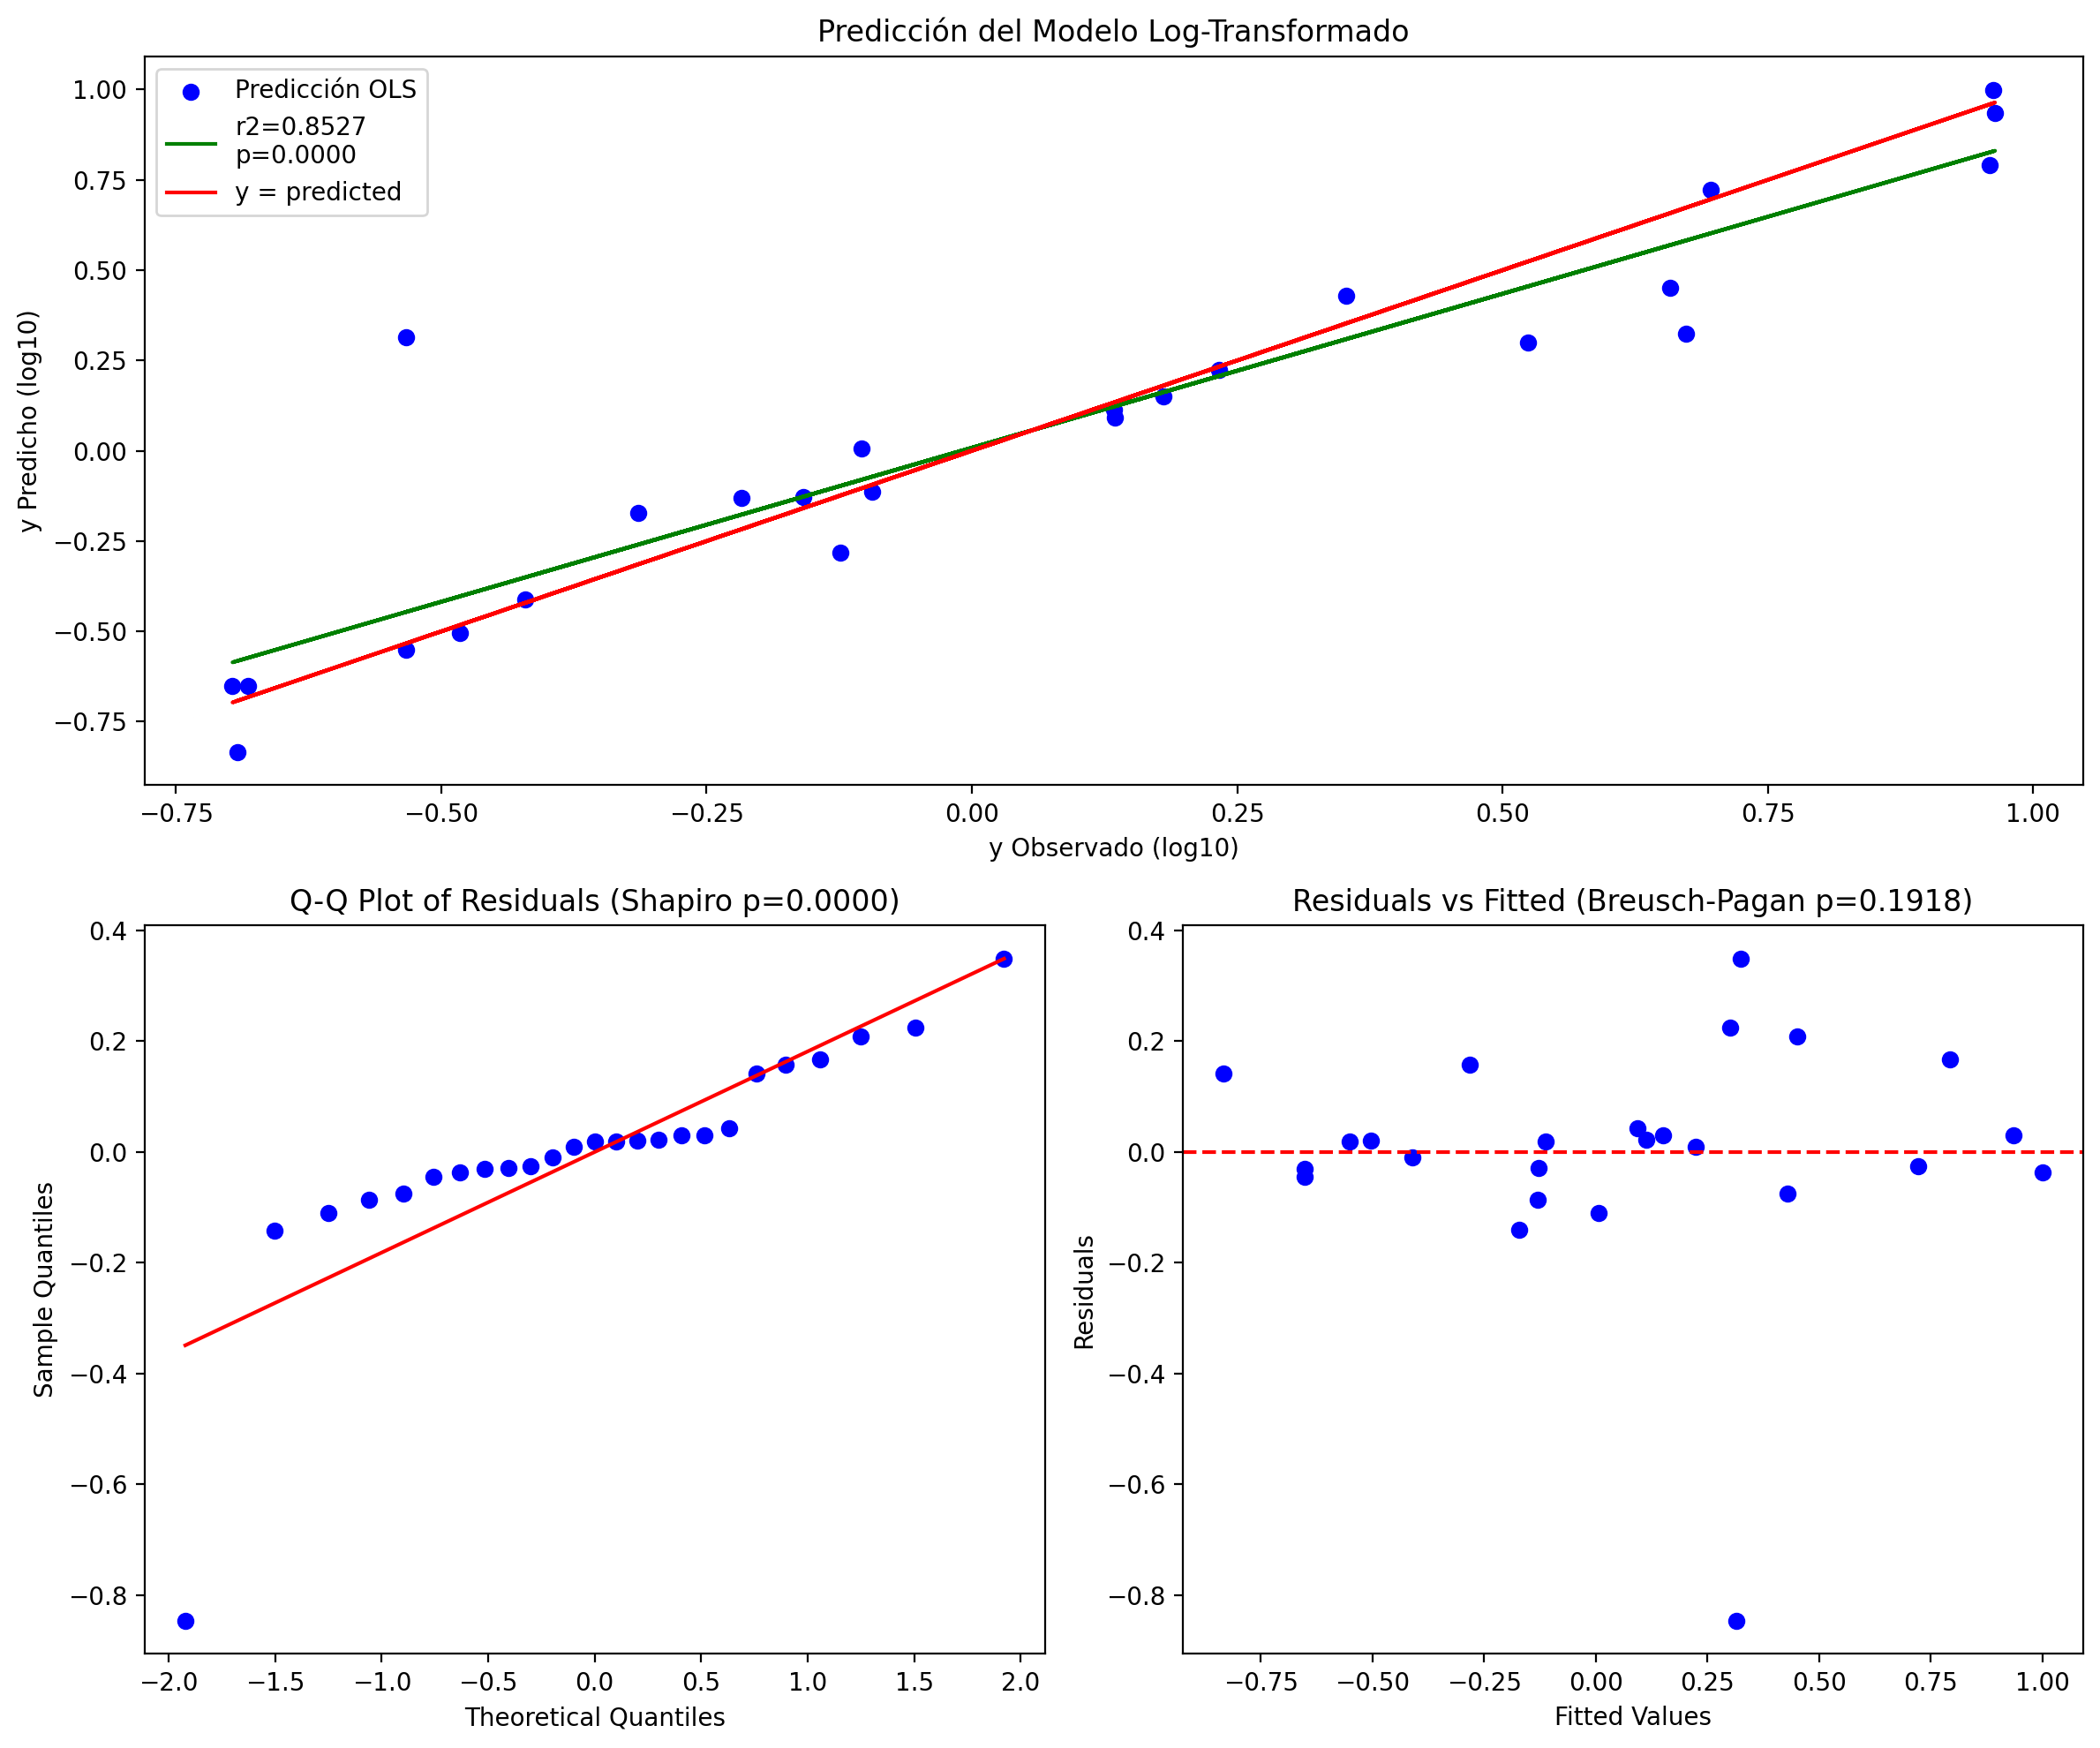


Shapiro-Wilk Test Result (Log-Transformed Model):
Statistic: 0.7208, p-value: 1.4079e-05

Breusch-Pagan Test Result (Log-Transformed Model):
Lagrange Multiplier Statistic: 6.1005, p-value: 1.9177e-01


In [65]:
# verificamos supuestos de RL
res_log = jet_log_ols.resid

fig, ax = plt.subplot_mosaic([
    ['ajuste', 'ajuste'],
    ['qq', 'resid']
], figsize=(12, 10), dpi=200)

# Gráfico de Ajuste 
ax['ajuste'].scatter(jet_log['y'], jet_log_ols.fittedvalues, color='blue', label='Predicción OLS')
slope, intercept, r_value, p_value, std_err = stats.linregress(jet_log['y'], jet_log_ols.fittedvalues)
ax['ajuste'].plot(jet_log['y'], slope * jet_log['y'] + intercept, color='green', label=f'r2={r_value**2:.4f}\np={p_value:.4f}')
ax['ajuste'].plot(jet_log['y'], jet_log['y'], color='red', label='y = predicted')
ax['ajuste'].set_xlabel('y Observado (log10)')
ax['ajuste'].set_ylabel('y Predicho (log10)')
ax['ajuste'].set_title('Predicción del Modelo Log-Transformado')
ax['ajuste'].legend()

# Q-Q Plot con Shapiro-Wilk 
(osm, osr), (slope_qq, intercept_qq, r) = stats.probplot(res_log, dist="norm")
ax['qq'].scatter(osm, osr, color='blue')
ax['qq'].plot(osm, slope_qq * osm + intercept_qq, 'r')
ax['qq'].set_xlabel('Theoretical Quantiles')
ax['qq'].set_ylabel('Sample Quantiles')
shapiro_result_log = stats.shapiro(res_log)
ax['qq'].set_title(f'Q-Q Plot of Residuals (Shapiro p={shapiro_result_log.pvalue:.4f})')

# Residuals vs Fitted con Breusch-Pagan 
ax['resid'].scatter(jet_log_ols.fittedvalues, res_log, color='blue')
ax['resid'].axhline(0, color='red', linestyle='--')
ax['resid'].set_xlabel('Fitted Values')
ax['resid'].set_ylabel('Residuals')
bp_test_log = sm.stats.diagnostic.het_breuschpagan(res_log, jet_log_ols.model.exog)
ax['resid'].set_title(f'Residuals vs Fitted (Breusch-Pagan p={bp_test_log[1]:.4f})')

plt.tight_layout()
plt.show()

# Tests formales adicionales
print("\nShapiro-Wilk Test Result (Log-Transformed Model):")
print(f"Statistic: {shapiro_result_log.statistic:.4f}, p-value: {shapiro_result_log.pvalue:.4e}")

print("\nBreusch-Pagan Test Result (Log-Transformed Model):")
print(f"Lagrange Multiplier Statistic: {bp_test_log[0]:.4f}, p-value: {bp_test_log[1]:.4e}")

## h)

Haga un análisis de outliers del modelo 3g). ¿Existen outliers? Si existen, elimine el punto más extremo y vuelva a recalcular el modelo repitiendo el proceso indicado en 3g). ¿Mejoró la eliminación de ell(los) outlier(s) las condiciones y desempeño del nuevo modelo? Comente brevemente.

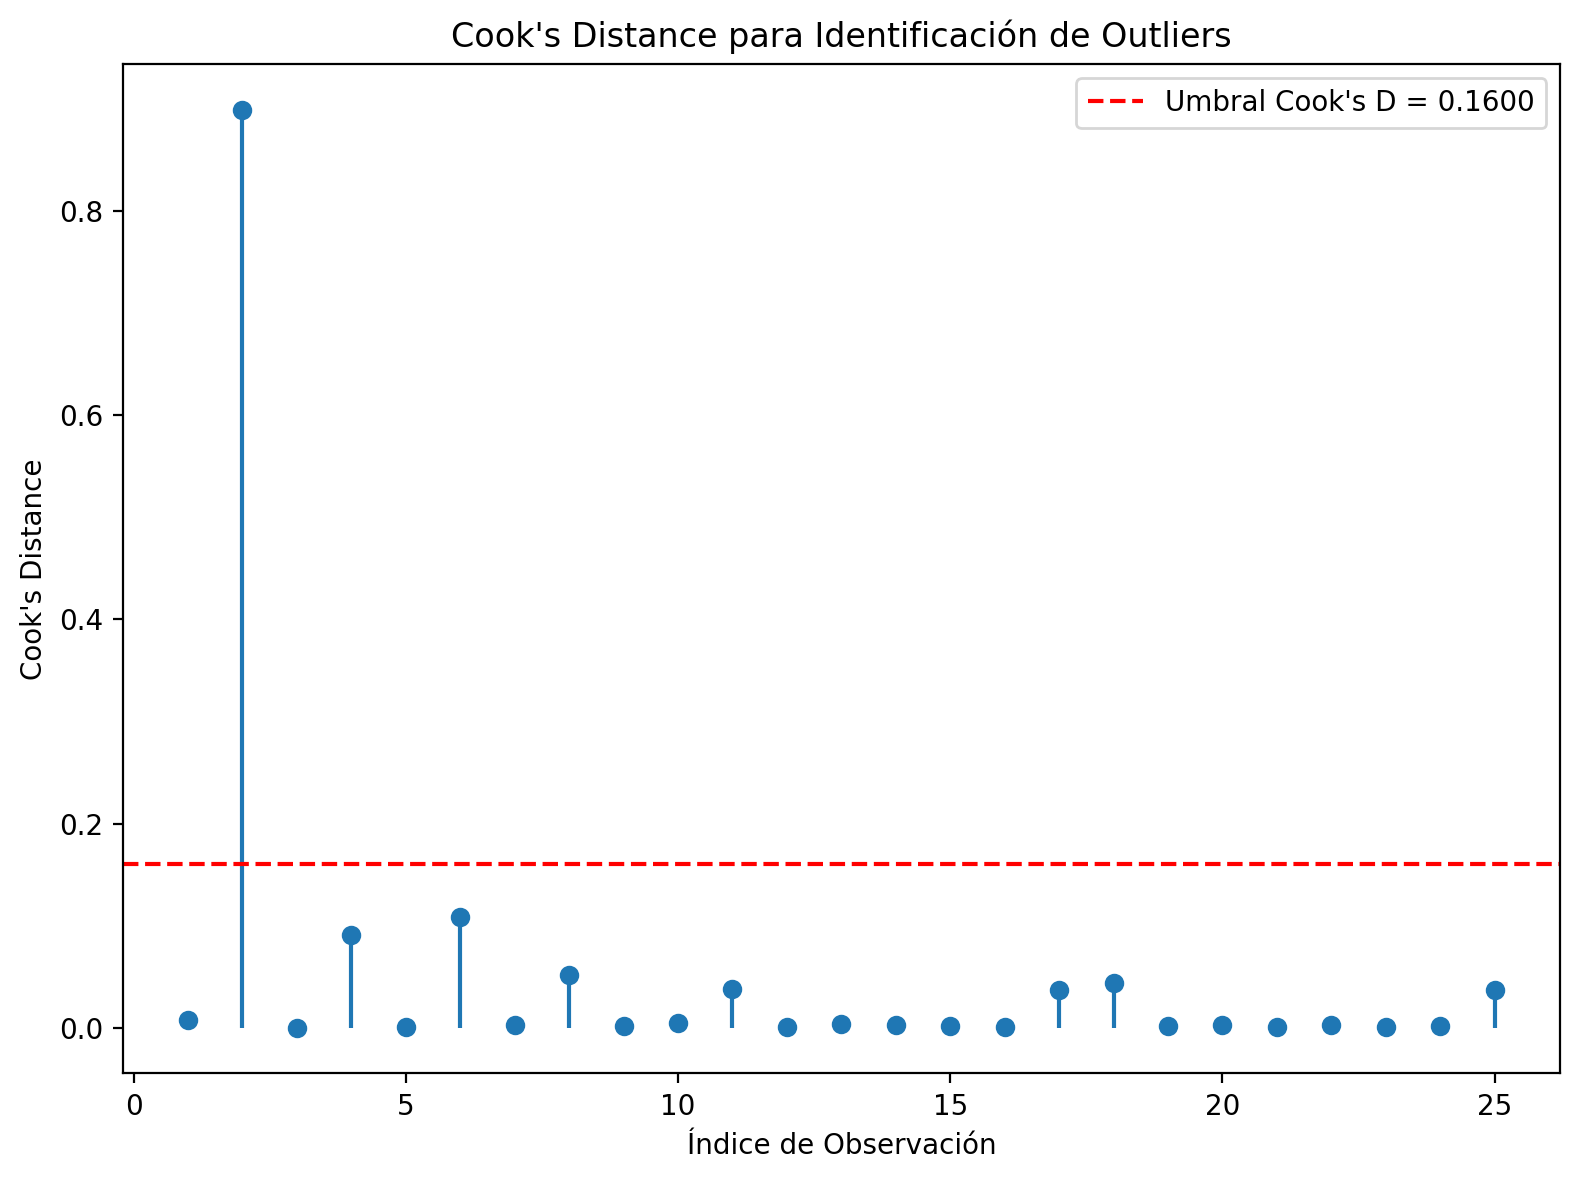

In [75]:
import numpy as np
from statsmodels.formula.api import ols

# Para evitar borrar múltiples puntos si corres esta celda varias veces, 
# reconstruimos jet_log desde el original cada vez.
jet_log_base = jet_df.copy()
jet_log_base.drop(columns=['x5'], inplace=True)
jet_log_base = np.log10(jet_log_base)

modelo_ini = ols('y ~ x1 + x2 + x3 + x4', data=jet_log_base).fit()


influencia = modelo_ini.get_influence()
cooks_d = influencia.cooks_distance[0]

n = len(jet_log_base)
umbral_cook = 4 / n

indices_outliers = jet_log_base.index[cooks_d > umbral_cook]
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
ax.stem(jet_log_base.index, cooks_d, markerfmt='o', basefmt=' ')
ax.axhline(umbral_cook, color='red', linestyle='--', label=f'Umbral Cook\'s D = {umbral_cook:.4f}')
ax.set_xlabel('Índice de Observación')
ax.set_ylabel('Cook\'s Distance')
ax.set_title('Cook\'s Distance para Identificación de Outliers')
ax.legend()
plt.tight_layout()

In [ ]:

jet_log_cleaned = jet_log_base.drop(index=indices_outliers)

jet_log_ols_cleaned = ols('y ~ x1 + x2 + x3 + x4', data=jet_log_cleaned).fit()

print("\nLog-Transformed OLS Regression Summary (Después de eliminar outliers por Cook):")
print(jet_log_ols_cleaned.summary())


Log-Transformed OLS Regression Summary (Después de eliminar outliers por Cook):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     203.7
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.57e-15
Time:                        23:43:07   Log-Likelihood:                 26.385
No. Observations:                  24   AIC:                            -42.77
Df Residuals:                      19   BIC:                            -36.88
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

El modelo mejoro bastante, probemos ahora verificando los supuestos.

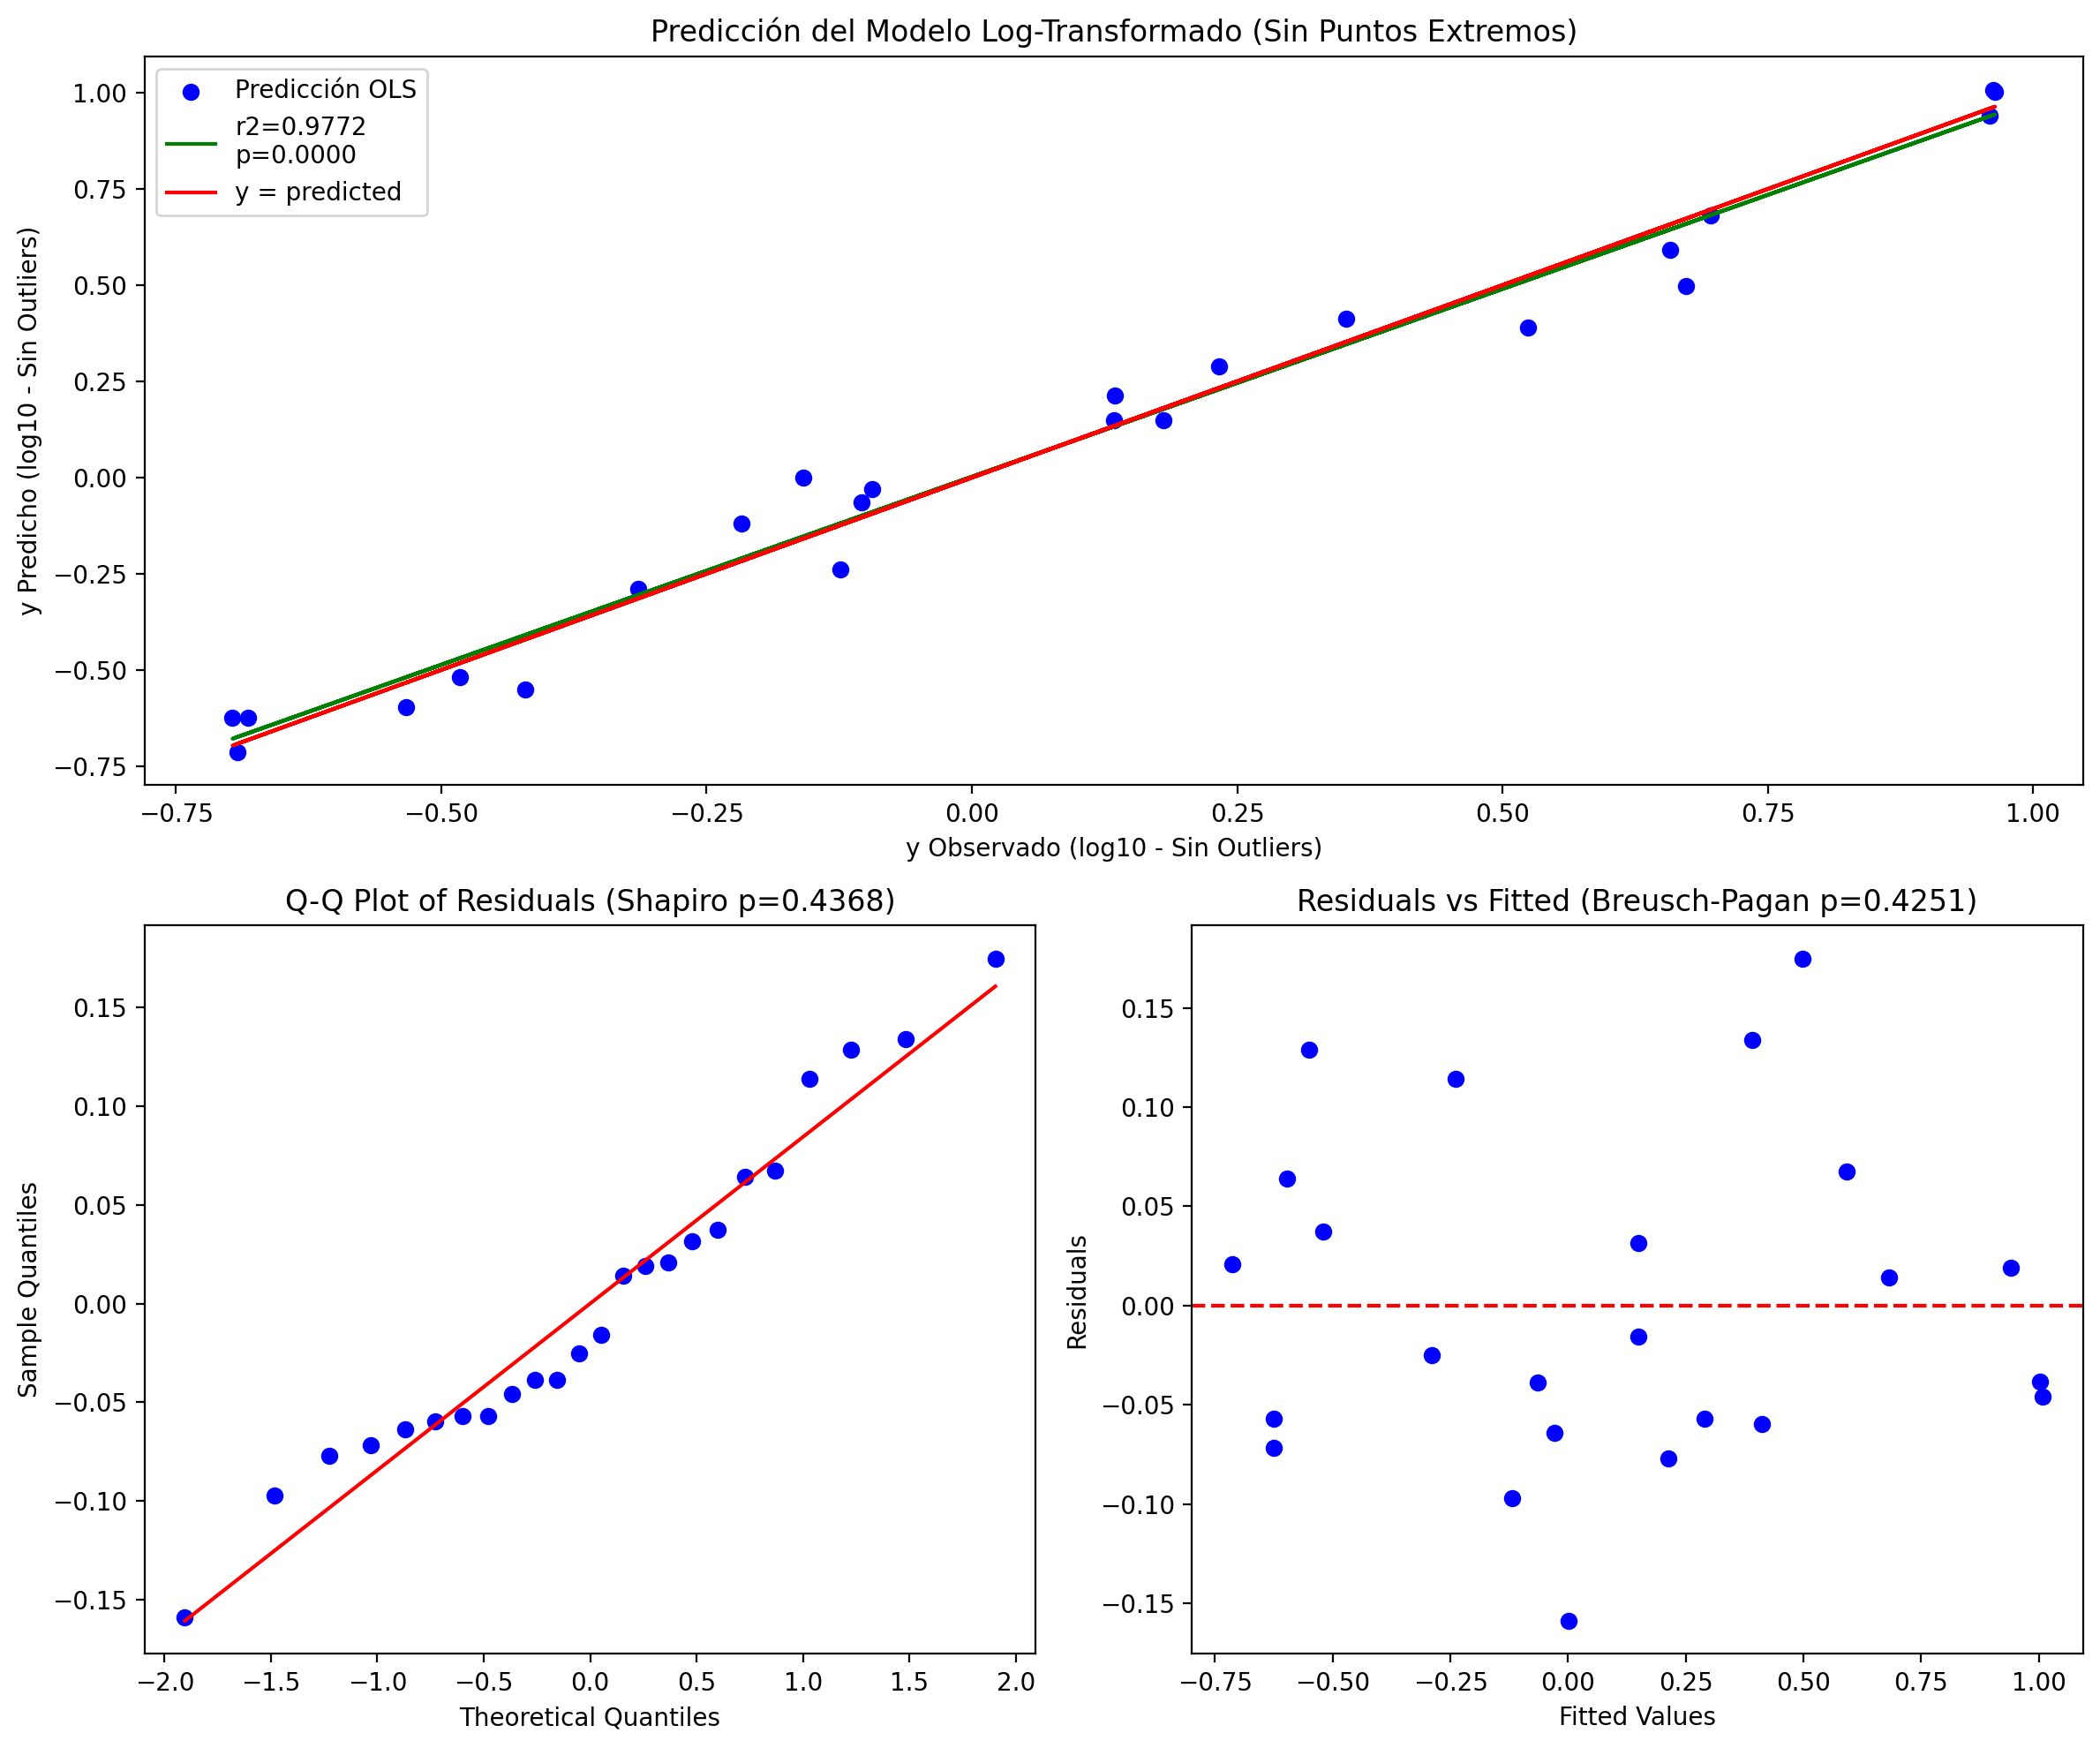


Shapiro-Wilk Test Result (Log-Transformed Model After Removing Exteme Point):
Statistic: 0.9599, p-value: 4.3680e-01

Breusch-Pagan Test Result (Log-Transformed Model After Removing Extreme Point):
Lagrange Multiplier Statistic: 3.8610, p-value: 4.2514e-01


In [78]:
residuos_log = jet_log_ols_cleaned.resid

fig, ax = plt.subplot_mosaic([
    ['ajuste', 'ajuste'],
    ['qq', 'resid']
], figsize=(12, 10), dpi=200)

# Gráfico de Ajuste 
ax['ajuste'].scatter(jet_log_cleaned['y'], jet_log_ols_cleaned.fittedvalues, color='blue', label='Predicción OLS')
slope, intercept, r_value, p_value, std_err = stats.linregress(jet_log_cleaned['y'], jet_log_ols_cleaned.fittedvalues)
ax['ajuste'].plot(jet_log_cleaned['y'], slope * jet_log_cleaned['y'] + intercept, color='green', label=f'r2={r_value**2:.4f}\np={p_value:.4f}')
ax['ajuste'].plot(jet_log_cleaned['y'], jet_log_cleaned['y'], color='red', label='y = predicted')
ax['ajuste'].set_xlabel('y Observado (log10 - Sin Outliers)')
ax['ajuste'].set_ylabel('y Predicho (log10 - Sin Outliers)')
ax['ajuste'].set_title('Predicción del Modelo Log-Transformado (Sin Puntos Extremos)')
ax['ajuste'].legend()

# Q-Q Plot con Shapiro-Wilk 
(osm, osr), (slope_qq, intercept_qq, r) = stats.probplot(residuos_log, dist="norm")
ax['qq'].scatter(osm, osr, color='blue')
ax['qq'].plot(osm, slope_qq * osm + intercept_qq, 'r')
ax['qq'].set_xlabel('Theoretical Quantiles')
ax['qq'].set_ylabel('Sample Quantiles')
shapiro_result_log_cleaned = stats.shapiro(residuos_log)
ax['qq'].set_title(f'Q-Q Plot of Residuals (Shapiro p={shapiro_result_log_cleaned.pvalue:.4f})')

# Residuals vs Fitted con Breusch-Pagan 
ax['resid'].scatter(jet_log_ols_cleaned.fittedvalues, residuos_log, color='blue')
ax['resid'].axhline(0, color='red', linestyle='--')
ax['resid'].set_xlabel('Fitted Values')
ax['resid'].set_ylabel('Residuals')
bp_test_log_cleaned = sm.stats.diagnostic.het_breuschpagan(residuos_log, jet_log_ols_cleaned.model.exog)
ax['resid'].set_title(f'Residuals vs Fitted (Breusch-Pagan p={bp_test_log_cleaned[1]:.4f})')

plt.tight_layout()
plt.show()

# Tests formales adicionales
print("\nShapiro-Wilk Test Result (Log-Transformed Model After Removing Exteme Point):")
print(f"Statistic: {shapiro_result_log_cleaned.statistic:.4f}, p-value: {shapiro_result_log_cleaned.pvalue:.4e}")

print("\nBreusch-Pagan Test Result (Log-Transformed Model After Removing Extreme Point):")
print(f"Lagrange Multiplier Statistic: {bp_test_log_cleaned[0]:.4f}, p-value: {bp_test_log_cleaned[1]:.4e}")

Se cumplen ambos supuestos 